In [2]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4_entropictest3있음중요함!!/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


Missing keys: ['ghead2.0.weight', 'ghead2.0.bias', 'ghead2.1.weight', 'ghead2.1.bias', 'ghead2.4.weight', 'ghead2.4.bias']
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=64, bias=True)
    (k_proj): Linear(in_features=768, out_features=64, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_la

In [3]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_3
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_3.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_4
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_4.pkl
Training data size: 600
Va

In [4]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





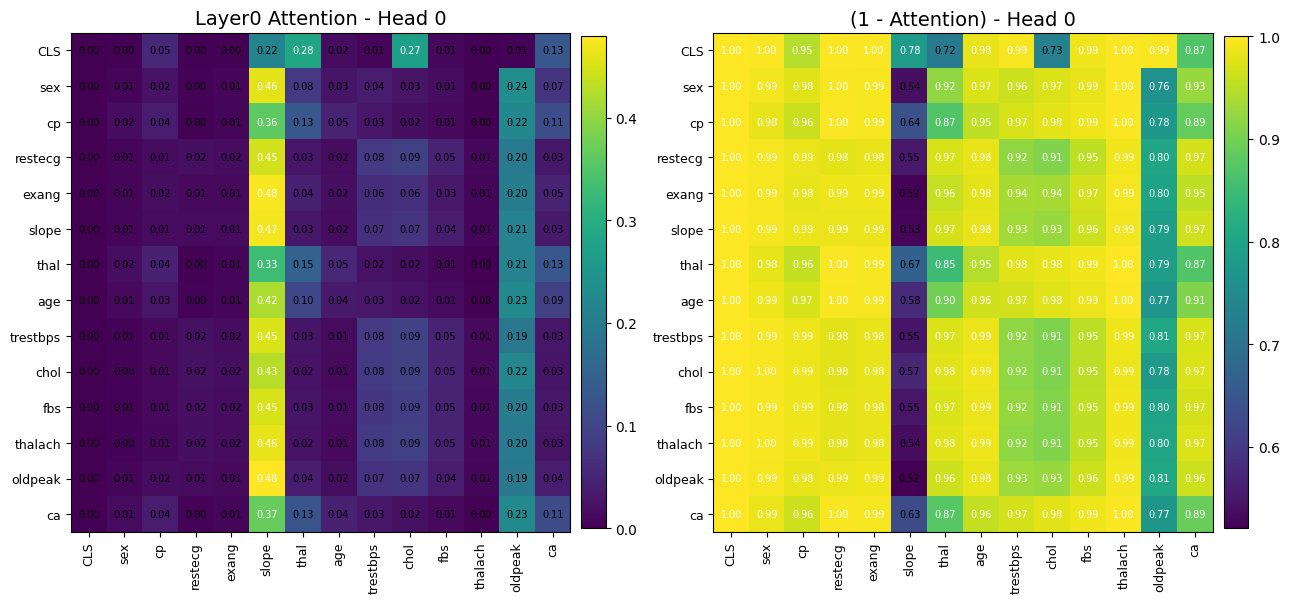

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=-0.0064 | std=0.1725
            sex  | mean=0.0273 | std=2.2283
             cp  | mean=0.2730 | std=5.9895
        restecg  | mean=0.3063 | std=6.4797
          exang  | mean=0.0647 | std=2.6687
          slope  | mean=0.2243 | std=5.7101
           thal  | mean=0.2235 | std=5.3897
            age  | mean=-0.1372 | std=6.3874
       trestbps  | mean=0.0011 | std=0.2413
           chol  | mean=-0.2094 | std=4.6240
            fbs  | mean=-0.1009 | std=2.1943
        thalach  | mean=0.6118 | std=14.2176
        oldpeak  | mean=-0.2305 | std=5.2973
             ca  | mean=-0.0513 | std=2.0691

=== Global embedding statistics ===
global mean: 0.0712
global std : 5.6938


In [6]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



In [8]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# from sklearn.cluster import KMeans
# from sklearn.manifold import TSNE

# def simulate_and_visualize_strategies(model, loaders, device, M=8, K=8, num_vis_samples=3000):
#     print(f"\n{'='*10} Simulating LCG Initialization Strategies {'='*10}")
    
#     # --- Step 1. Collect Pre-trained CLS Tokens ---
#     print(">> 1. Collecting CLS tokens from Vanilla GAT...")
#     all_cls = []
#     model.eval()
    
#     with torch.no_grad():
#         for src_name, loader in loaders.items():
#             for batch in loader:
#                 batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
#                 # GAT Forward Logic (CLS Extraction)
#                 name_embs, val_embs = [], []
#                 if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
#                 if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
#                 if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
#                 if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
#                 if not name_embs: continue
#                 name = torch.cat(name_embs, dim=1)
#                 val = torch.cat(val_embs, dim=1)
                
#                 x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
#                 for l in range(model.num_basis_layers):
#                     norm_x = model.basis_layer_norms[l](x_basis)
#                     basis_outputs, _ = model.basis_layers[l](name, norm_x)
#                     x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
#                 # CLS Token (Index 0)
#                 cls_token = x_basis[:, 0, :].cpu().numpy()
#                 all_cls.append(cls_token)
                
#                 # 너무 많으면 메모리 터지니 2만개 정도만 수집
#                 if sum([len(x) for x in all_cls]) > 20000: break
    
#     pool_cls = np.concatenate(all_cls, axis=0)
#     print(f"   >> Total CLS Collected: {pool_cls.shape[0]}")

#     # --- Step 2. Define Strategies ---
#     strategies = ['hierarchical', 'round_robin', 'sequential', 'density']
    
#     # 시각화용 Figure 생성 (2x2 Grid)
#     fig, axes = plt.subplots(2, 2, figsize=(20, 18))
#     axes = axes.flatten()
    
#     # t-SNE를 위한 배경 데이터 샘플링 (속도 최적화)
#     if pool_cls.shape[0] > num_vis_samples:
#         idx = np.random.choice(pool_cls.shape[0], num_vis_samples, replace=False)
#         vis_cls = pool_cls[idx]
#     else:
#         vis_cls = pool_cls

#     for i, strategy in enumerate(strategies):
#         print(f">> Simulating Strategy: [{strategy.upper()}]...")
        
#         # --- Logic per Strategy ---
#         centroids = None # Shape: [M, K, D]
        
#         if strategy in ['sequential', 'round_robin', 'density']:
#             # Global KMeans
#             kmeans = KMeans(n_clusters=M*K, n_init=10, random_state=42).fit(pool_cls)
#             centers = kmeans.cluster_centers_
            
#             if strategy == 'sequential':
#                 # [M*K, D] -> [M, K, D]
#                 centroids = centers.reshape(M, K, -1)
                
#             elif strategy == 'round_robin':
#                 # [M*K, D] -> [K, M, D] -> Transpose -> [M, K, D]
#                 centroids = centers.reshape(K, M, -1).transpose(1, 0, 2)
                
#             elif strategy == 'density':
#                 # Sort by cluster size
#                 labels = kmeans.labels_
#                 counts = np.bincount(labels, minlength=M*K)
#                 sorted_idx = np.argsort(counts)[::-1] # Descending
#                 centroids = centers[sorted_idx].reshape(M, K, -1)
                
#         elif strategy == 'hierarchical':
#             # 2-Step KMeans
#             centroids = np.zeros((M, K, pool_cls.shape[1]))
#             km_global = KMeans(n_clusters=M, n_init=10, random_state=42).fit(pool_cls)
            
#             for m in range(M):
#                 group = pool_cls[km_global.labels_ == m]
#                 # 데이터 부족 시 보충
#                 if len(group) < K:
#                     supp = pool_cls[np.random.choice(len(pool_cls), K - len(group))]
#                     group = np.concatenate([group, supp], axis=0)
                    
#                 km_local = KMeans(n_clusters=K, n_init=10, random_state=42).fit(group)
#                 centroids[m] = km_local.cluster_centers_

#         # --- Step 3. t-SNE & Plotting ---
#         # [CLS + Centroids]를 합쳐서 t-SNE 수행
#         flat_centroids = centroids.reshape(-1, centroids.shape[-1])
#         all_data = np.concatenate([vis_cls, flat_centroids], axis=0)
        
#         # t-SNE (Perplexity 낮춤 for sparse centroids)
#         tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
#         embedded = tsne.fit_transform(all_data)
        
#         idx_split = vis_cls.shape[0]
#         emb_cls = embedded[:idx_split]
#         emb_cen = embedded[idx_split:]
        
#         # Plot
#         ax = axes[i]
#         # 배경 (Source CLS)
#         ax.scatter(emb_cls[:, 0], emb_cls[:, 1], c='lightgray', alpha=0.2, s=20, label='Source CLS')
        
#         # Centroids (Color by Graph ID)
#         colors = cm.rainbow(np.linspace(0, 1, M))
#         for m in range(M):
#             start = m * K
#             end = (m + 1) * K
#             subset = emb_cen[start:end]
#             ax.scatter(subset[:, 0], subset[:, 1], color=colors[m], marker='o', s=100, 
#                        edgecolor='black', linewidth=1.5, label=f'Graph {m}' if i==0 else "")
            
#         ax.set_title(f"Strategy: {strategy.upper()}")
#         if i == 0: ax.legend(loc='best', ncol=2, fontsize=8)

#     plt.tight_layout()
#     plt.show()

# # 실행
# simulate_and_visualize_strategies(model, loaders, device, M=8, K=8)

### Affinity Two sample

In [9]:
import numpy as np
from collections import defaultdict
@torch.no_grad()
def collect_all_samples_from_source(model, loader, source_name):
    """
    한 source의 모든 샘플에 대해 node embedding과 affinity 추출
    
    Returns:
        all_embeddings: list of [N, D] arrays (CLS 제외한 variable nodes만)
        all_affinities: list of [N, N] arrays (1 - attention, Var-Var만)
        all_labels: list of labels
        all_feature_names: list of feature name lists
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []
    
    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        
        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None
        
        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            
            # attention shape: [B, H, T, T]
            last_att = att
            
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B, H, T, T]
        # Head 0 사용
        last_att = last_att[:, 0, :, :]  # [B, T, T]
        
        # Feature names
        var_names = extract_feature_names(batch)
        
        for b in range(B):
            # CLS 제외 (1:부터)
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N, D]
            
            # Var-Var attention만 (CLS 제외)
            var_att = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N, N]
            
            # 1 - attention = distance/affinity
            affinity = 1.0 - var_att
            
            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(batch['y'][b].item())
            all_feature_names.append(var_names)
    
    return all_embeddings, all_affinities, all_labels, all_feature_names

def compute_frobenius_distances(embeddings, affinities):
    """
    모든 샘플 쌍의 Frobenius distance 계산
    
    Returns:
        emb_distances: [n_samples, n_samples] embedding Frobenius distances
        aff_distances: [n_samples, n_samples] affinity Frobenius distances
    """
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            # Embedding Frobenius distance
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff
            
            # Affinity Frobenius distance
            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff
    
    return emb_distances, aff_distances

def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    """
    Reference 샘플과 같은/다른 레이블 내에서 가장 유사/상이한 샘플 찾기
    
    Returns:
        most_similar_same_label_idx: 같은 레이블 중 가장 유사
        most_different_other_label_idx: 다른 레이블 중 가장 상이
    """
    n = len(distances)
    ref_label = labels[reference_idx]
    
    # 같은 레이블 샘플들
    same_label_mask = np.array([labels[i] == ref_label for i in range(n)])
    same_label_mask[reference_idx] = False  # 자기자신 제외
    
    # 다른 레이블 샘플들
    other_label_mask = np.array([labels[i] != ref_label for i in range(n)])
    
    # 같은 레이블 중 가장 유사 (거리 최소)
    dist_same_label = distances[reference_idx].copy()
    dist_same_label[~same_label_mask] = np.inf
    most_similar_same_label_idx = np.argmin(dist_same_label)
    
    # 다른 레이블 중 가장 상이 (거리 최대)
    dist_other_label = distances[reference_idx].copy()
    dist_other_label[~other_label_mask] = -np.inf
    most_different_other_label_idx = np.argmax(dist_other_label)
    
    return most_similar_same_label_idx, most_different_other_label_idx

In [10]:
# 1. 데이터 수집
src = sources[1]  # 첫 번째 source
loader = loaders[src]

print(f"Collecting samples from source: {src}")
embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(model, loader, src)

print(f"Total samples collected: {len(embeddings)}")
print(f"Node embedding shape: {embeddings[0].shape}")
print(f"Affinity shape: {affinities[0].shape}")

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)


In [11]:
# 2. Frobenius distance 계산
print("Computing Frobenius distances...")
emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

print(f"Embedding distance matrix shape: {emb_distances.shape}")
print(f"Affinity distance matrix shape: {aff_distances.shape}")

Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)


In [12]:
# 3. Reference 샘플 선택 (예: 첫 번째 샘플)
reference_idx = 0

# Affinity 기준으로 같은 레이블에서 가장 유사, 다른 레이블에서 가장 상이한 샘플 찾기
similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, aff_distances, labels)

print(f"\n=== Analysis based on Affinity Frobenius Distance (Label-aware) ===")
print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")


=== Analysis based on Affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 1)

Most similar (SAME label): 242 (label: 1)
  → Affinity Frobenius distance: 0.1275

Most different (OTHER label): 141 (label: 0)
  → Affinity Frobenius distance: 0.7756



=== Reference Sample Affinity ===


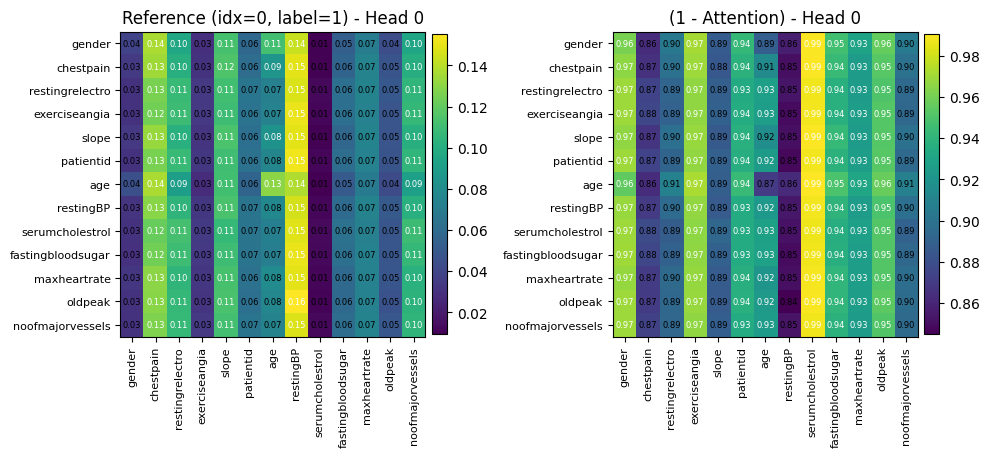


=== Most Similar Sample (SAME Label) Affinity ===
Frobenius distance: 0.1275


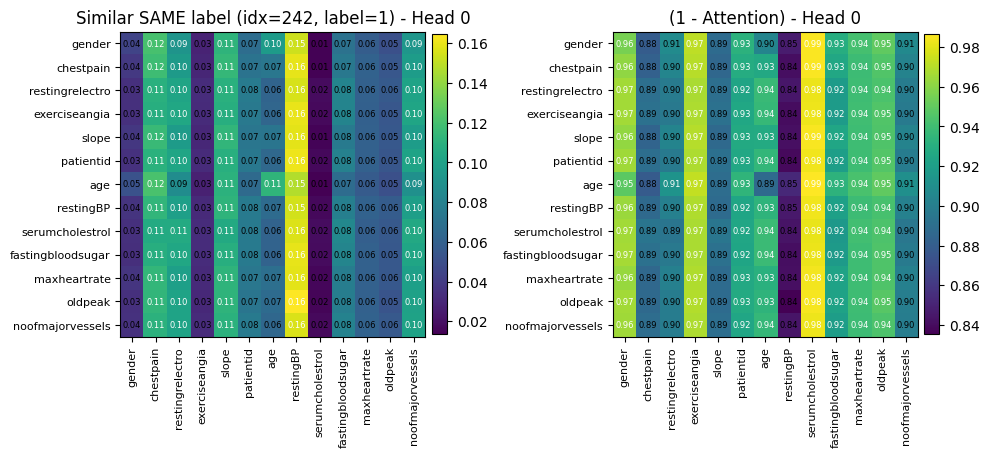


=== Most Different Sample (OTHER Label) Affinity ===
Frobenius distance: 0.7756


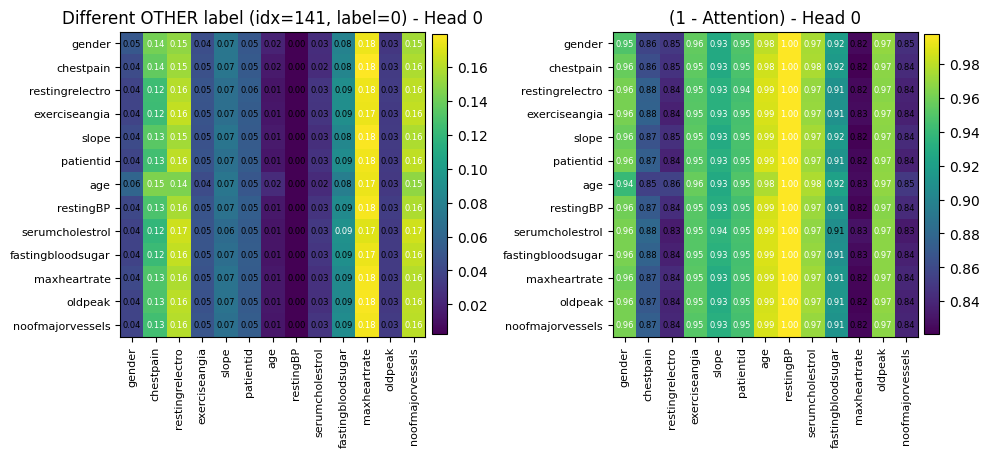

In [13]:
# 4. 시각화
feature_names = ["CLS"] + feature_names_list[0]
var_names = feature_names_list[0]

# Reference 샘플 affinity
ref_aff = affinities[reference_idx]
# Most similar (same label) 샘플 affinity
sim_aff = affinities[similar_idx]
# Most different (other label) 샘플 affinity
diff_aff = affinities[different_idx]

# 3D attention shape로 변환 (plot 함수 호환)
ref_aff_3d = ref_aff[np.newaxis, :, :]  # [1, N, N]
sim_aff_3d = sim_aff[np.newaxis, :, :]
diff_aff_3d = diff_aff[np.newaxis, :, :]

print("\n=== Reference Sample Affinity ===")
plot_attention_with_inverse(
    att=1.0 - ref_aff_3d,  # affinity를 다시 attention으로
    feature_names=var_names,
    title=f"Reference (idx={reference_idx}, label={labels[reference_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Similar Sample (SAME Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - sim_aff_3d,
    feature_names=var_names,
    title=f"Similar SAME label (idx={similar_idx}, label={labels[similar_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Different Sample (OTHER Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - diff_aff_3d,
    feature_names=var_names,
    title=f"Different OTHER label (idx={different_idx}, label={labels[different_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

In [14]:
# Joint 모델 로드
#joint_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest3/42/best.pt"
joint_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-v5/42/best.pt"
joint_ckpt = torch.load(joint_ckpt_path, map_location=device)
joint_args = joint_ckpt['args']

# Joint 모델 초기화
joint_model = Model(
    joint_args,
    joint_args.input_dim,
    joint_args.hidden_dim,
    joint_args.output_dim,
    joint_args.dropout_rate,
    joint_args.llm_model,
    experiment_id="joint_viz",
    mode="Full"
).to(device)

joint_sd = joint_ckpt['model_state_dict']
missing, unexpected = joint_model.load_state_dict(joint_sd, strict=False)
print("Joint Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

joint_model.eval()

Joint Model Loaded
Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=64, bias=True)
    (k_proj): Linear(in_features=768, out_features=64, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_la

In [15]:
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities):
    """
    3개 샘플 (ref, similar, different) x 8개 LCG = 24개 Transport Plan 계산
    
    Args:
        model: Joint trained model
        sample_indices: [ref_idx, similar_idx, different_idx]
        embeddings: list of node embeddings
        affinities: list of affinity matrices
    
    Returns:
        plans: [3, 8, N, K] Transport Plans
        distances: [3, 8] FGW distances
        coordinates: [3, 8] Soft assignments (pi)
    """
    # LCG 가져오기
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    n_samples = len(sample_indices)
    
    # 결과 저장
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        # Source 준비
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)  # [1, N, D]
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)   # [1, N, N]
        
        N = src_feat.shape[1]
        
        # Expand for M LCGs
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)  # [M, N, D]
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)    # [M, N, N]
        
        # LCG 준비
        lcg_feat_exp = lcg_feat  # [M, K, D]
        lcg_str_exp = lcg_struct  # [M, K, K]
        
        # FGW 계산 (GraphQuantizer의 compute_fgw 재현)
        dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = model.graph_quantizer.alpha
        reg = model.graph_quantizer.reg
        
        # Solve FGW
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach().cpu().numpy()  # [M]
        plans = result.plan.detach().cpu().numpy()       # [M, N, K]
        
        # Soft assignment (pi)
        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]
        
        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)
    
    all_plans = np.array(all_plans)           # [3, M, N, K]
    all_distances = np.array(all_distances)   # [3, M]
    all_coordinates = np.array(all_coordinates)  # [3, M]
    
    return all_plans, all_distances, all_coordinates

In [16]:
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    """
    3 x 8 Grid로 Transport Plan 시각화
    + 각 LCG별로 Reference vs Similar, Reference vs Different의 Frobenius norm 표시
    
    Args:
        plans: [3, 8, N, K]
        coordinates: [3, 8] (pi values)
        distances: [3, 8] (FGW distances)
        sample_indices: [ref_idx, similar_idx, different_idx]
        labels: list of all labels
        var_names: list of variable names
    """
    n_samples = 3
    n_lcgs = 8
    
    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    
    # 각 LCG별 Frobenius norm 계산
    frob_norms_similar = []  # Reference vs Similar
    frob_norms_different = []  # Reference vs Different
    
    for j in range(n_lcgs):
        plan_ref = plans[0, j]      # Reference
        plan_sim = plans[1, j]      # Similar
        plan_diff = plans[2, j]     # Different
        
        frob_ref_sim = np.linalg.norm(plan_ref - plan_sim, ord='fro')
        frob_ref_diff = np.linalg.norm(plan_ref - plan_diff, ord='fro')
        
        frob_norms_similar.append(frob_ref_sim)
        frob_norms_different.append(frob_ref_diff)
    
    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            
            plan = plans[i, j]  # [N, K]
            pi = coordinates[i, j]
            dist = distances[i, j]
            
            # Heatmap
            im = ax.imshow(plan, cmap='viridis', aspect='auto')
            
            # Title
            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)
            
            # Y-axis (Source variables)
            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})', 
                             fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])
            
            # X-axis (LCG nodes)
            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])
            
            # Frobenius norm 표시 (Different row의 맨 아래)
            if i == n_samples - 1:
                frob_sim = frob_norms_similar[j]
                frob_diff = frob_norms_different[j]
                
                # X-axis label 아래에 Frobenius norm 추가
                ax.text(0.5, -0.25, f'Frob: Sim={frob_sim:.3f} vs Diff={frob_diff:.3f}',
                       transform=ax.transAxes,
                       ha='center', va='top',
                       fontsize=8, color='red',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            
            # Colorbar
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)  # Frobenius norm 텍스트 공간 확보
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)', 
                 fontsize=14, y=0.99)
    plt.show()

In [17]:
# 실행
print("Computing Transport Plans for 3 samples x 8 LCGs...")
sample_indices = [reference_idx, similar_idx, different_idx]

plans, distances, coordinates = compute_transport_plans_for_samples(
    joint_model, sample_indices, embeddings, affinities
)

print(f"Plans shape: {plans.shape}")  # [3, 8, N, K]
print(f"Distances shape: {distances.shape}")  # [3, 8]
print(f"Coordinates shape: {coordinates.shape}")  # [3, 8]

print("\n=== Coordinates (pi) ===")
print("Reference:", coordinates[0])
print("Similar:", coordinates[1])
print("Different:", coordinates[2])

print("\n=== FGW Distances ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

Computing Transport Plans for 3 samples x 8 LCGs...
Plans shape: (3, 8, 13, 8)
Distances shape: (3, 8)
Coordinates shape: (3, 8)

=== Coordinates (pi) ===
Reference: [0.01001079 0.02437747 0.24506058 0.10814884 0.26239163 0.22373706
 0.0232956  0.1029781 ]
Similar: [0.01072693 0.00280888 0.3328355  0.1036732  0.2533654  0.1613526
 0.03914749 0.09609001]
Different: [5.6182048e-06 9.9764735e-01 1.2687667e-03 2.1473704e-04 2.4015490e-04
 4.7823036e-04 6.4410796e-07 1.4455587e-04]

=== FGW Distances ===
Reference: [0.00575237 0.00566337 0.00543259 0.00551439 0.00542575 0.00544169
 0.00566791 0.00551929]
Similar: [0.0066471  0.00678109 0.00630361 0.00642025 0.00633089 0.00637601
 0.00651764 0.00642784]
Different: [0.00658505 0.00537633 0.00604307 0.00622071 0.00620952 0.00614064
 0.00680164 0.00626028]


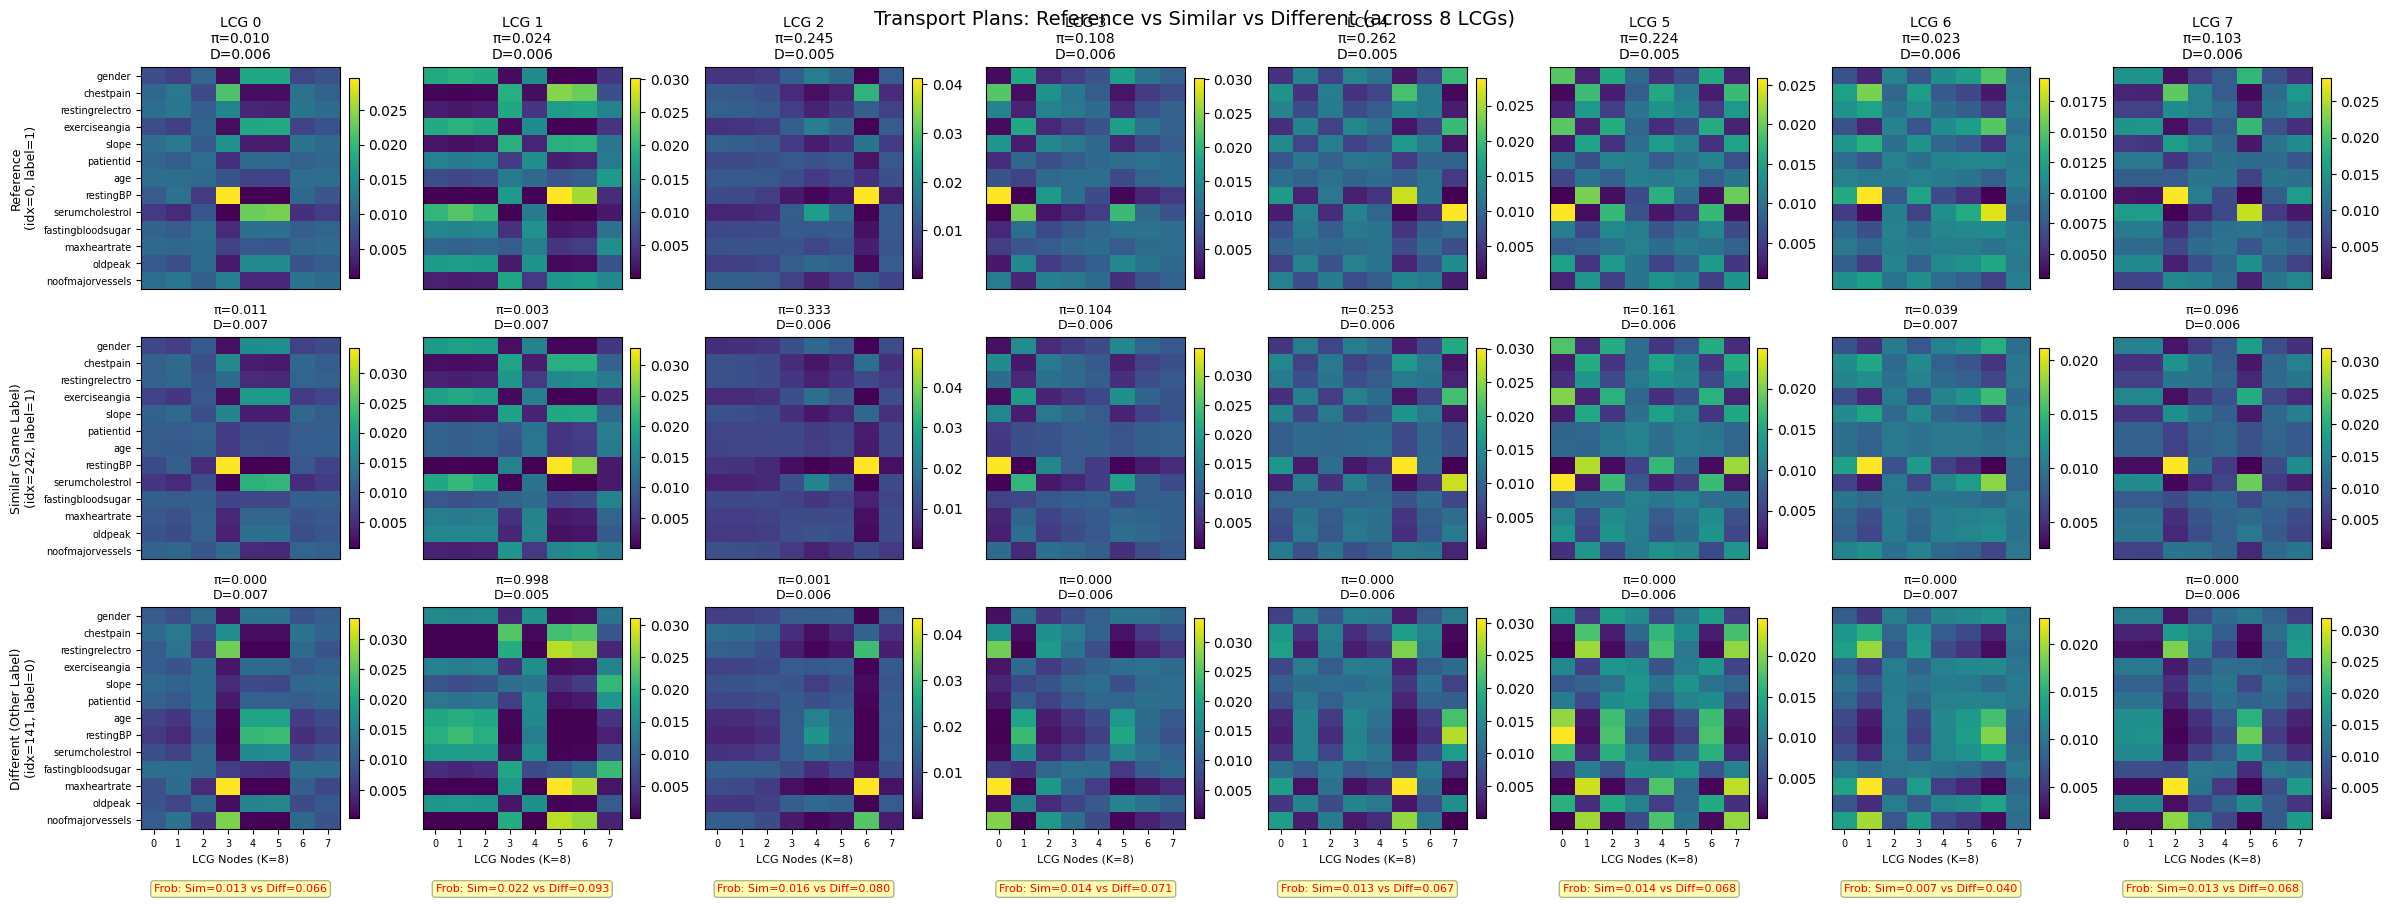

In [18]:
# 시각화
plot_transport_plans_grid(
    plans, coordinates, distances, 
    sample_indices, labels, var_names
)

In [19]:
# Pi (coordinates) 출력
print("=== Pi (Soft Assignment Probabilities) ===")
print("\nReference sample (idx={}, label={}):".format(reference_idx, labels[reference_idx]))
print(coordinates[0])
print(f"Sum: {coordinates[0].sum():.6f}")
print(f"Max: {coordinates[0].max():.4f}, Min: {coordinates[0].min():.4f}")
print(f"Std: {coordinates[0].std():.6f}")

print("\nSimilar sample (idx={}, label={}):".format(similar_idx, labels[similar_idx]))
print(coordinates[1])
print(f"Sum: {coordinates[1].sum():.6f}")
print(f"Max: {coordinates[1].max():.4f}, Min: {coordinates[1].min():.4f}")
print(f"Std: {coordinates[1].std():.6f}")

print("\nDifferent sample (idx={}, label={}):".format(different_idx, labels[different_idx]))
print(coordinates[2])
print(f"Sum: {coordinates[2].sum():.6f}")
print(f"Max: {coordinates[2].max():.4f}, Min: {coordinates[2].min():.4f}")
print(f"Std: {coordinates[2].std():.6f}")

print("\n=== Pi Comparison ===")
print("Reference vs Similar - Frobenius: {:.6f}".format(
    np.linalg.norm(coordinates[0] - coordinates[1])
))
print("Reference vs Different - Frobenius: {:.6f}".format(
    np.linalg.norm(coordinates[0] - coordinates[2])
))

# Raw distances (softmax 전)
print("\n=== Raw FGW Distances (before softmax) ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

print("\n=== Distance Comparison ===")
print("Reference vs Similar - Frobenius: {:.6f}".format(
    np.linalg.norm(distances[0] - distances[1])
))
print("Reference vs Different - Frobenius: {:.6f}".format(
    np.linalg.norm(distances[0] - distances[2])
))

=== Pi (Soft Assignment Probabilities) ===

Reference sample (idx=0, label=1):
[0.01001079 0.02437747 0.24506058 0.10814884 0.26239163 0.22373706
 0.0232956  0.1029781 ]
Sum: 1.000000
Max: 0.2624, Min: 0.0100
Std: 0.098425

Similar sample (idx=242, label=1):
[0.01072693 0.00280888 0.3328355  0.1036732  0.2533654  0.1613526
 0.03914749 0.09609001]
Sum: 1.000000
Max: 0.3328, Min: 0.0028
Std: 0.110479

Different sample (idx=141, label=0):
[5.6182048e-06 9.9764735e-01 1.2687667e-03 2.1473704e-04 2.4015490e-04
 4.7823036e-04 6.4410796e-07 1.4455587e-04]
Sum: 1.000000
Max: 0.9976, Min: 0.0000
Std: 0.329830

=== Pi Comparison ===
Reference vs Similar - Frobenius: 0.111634
Reference vs Different - Frobenius: 1.071505

=== Raw FGW Distances (before softmax) ===
Reference: [0.00575237 0.00566337 0.00543259 0.00551439 0.00542575 0.00544169
 0.00566791 0.00551929]
Similar: [0.0066471  0.00678109 0.00630361 0.00642025 0.00633089 0.00637601
 0.00651764 0.00642784]
Different: [0.00658505 0.00537633 0

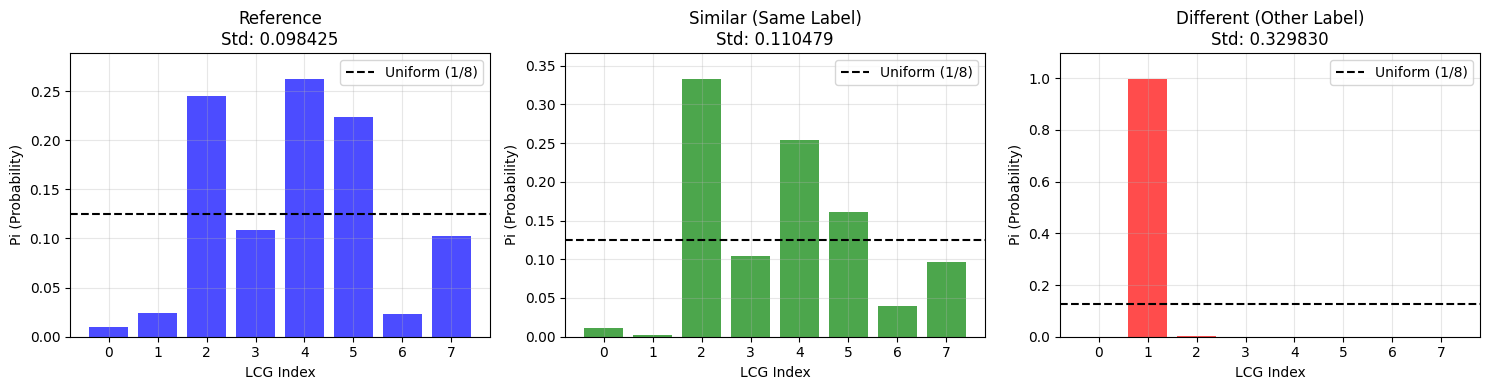

In [20]:
# 시각화: Pi 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# 더 자세한 분석: Distance의 variation
print("\n=== Distance Statistics Across Samples ===")
all_dists = np.array([distances[0], distances[1], distances[2]])

print("\nPer-LCG distance variance (across 3 samples):")
for lcg_idx in range(8):
    lcg_dists = all_dists[:, lcg_idx]
    print(f"LCG {lcg_idx}: mean={lcg_dists.mean():.6f}, std={lcg_dists.std():.6f}, range=[{lcg_dists.min():.6f}, {lcg_dists.max():.6f}]")

print("\nPer-Sample distance variance (across 8 LCGs):")
for sample_idx, name in enumerate(sample_names):
    sample_dists = all_dists[sample_idx]
    print(f"{name}: mean={sample_dists.mean():.6f}, std={sample_dists.std():.6f}")


=== Distance Statistics Across Samples ===

Per-LCG distance variance (across 3 samples):
LCG 0: mean=0.006328, std=0.000408, range=[0.005752, 0.006647]
LCG 1: mean=0.005940, std=0.000606, range=[0.005376, 0.006781]
LCG 2: mean=0.005926, std=0.000365, range=[0.005433, 0.006304]
LCG 3: mean=0.006052, std=0.000389, range=[0.005514, 0.006420]
LCG 4: mean=0.005989, std=0.000401, range=[0.005426, 0.006331]
LCG 5: mean=0.005986, std=0.000397, range=[0.005442, 0.006376]
LCG 6: mean=0.006329, std=0.000482, range=[0.005668, 0.006802]
LCG 7: mean=0.006069, std=0.000395, range=[0.005519, 0.006428]

Per-Sample distance variance (across 8 LCGs):
Reference: mean=0.005552, std=0.000118
Similar (Same Label): mean=0.006476, std=0.000154
Different (Other Label): mean=0.006205, std=0.000391


In [22]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

@torch.no_grad()
def collect_all_source_assignments(model, loaders, sources, device):
    """
    모든 source의 모든 샘플에 대해 LCG assignment 수집
    
    Returns:
        assignments: [N_total] - 각 샘플이 어느 LCG node에 할당되었는지
        source_labels: [N_total] - 각 샘플이 어느 source에서 왔는지
    """
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    all_assignments = []
    all_source_labels = []
    
    for src_idx, src in enumerate(sources):
        loader = loaders[src]
        
        for batch in loader:
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                    for k, v in batch.items()}
            
            # desc/name/value gather
            desc_embeddings, name_embeddings, value_embeddings = [], [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                desc_embeddings.append(batch['cat_desc_embeddings'])
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                desc_embeddings.append(batch['num_desc_embeddings'])
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name = torch.cat(name_embeddings, dim=1)
            value = torch.cat(value_embeddings, dim=1)
            
            B = value.size(0)
            N = value.size(1)

            # CLS + value
            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

            # GAT forward
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            # Source features (CLS 제외)
            src_feat = x_basis[:, 1:, :]  # [B, N, D]
            
            # Affinity (Var-Var, CLS 제외)
            src_str = 1.0 - last_att[:, 0, 1:, 1:]  # [B, N, N]
            
            # Expand for M LCGs
            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
            
            # FGW 계산
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            tau = model.graph_quantizer.tau
            M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
            
            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            
            alpha = model.graph_quantizer.alpha
            reg = model.graph_quantizer.reg
            
            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
                a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
            )
            
            # Transport Plan: [B*M, N, K] → [B, M, N, K]
            plan = result.plan.reshape(B, M, N, K)
            
            # 각 샘플의 각 node가 어느 LCG node에 가장 많이 할당되었는지
            # Plan shape: [B, M, N, K]
            # Max over (M, K) → 어느 (LCG, Node)에 가장 많이?
            plan_flat = plan.reshape(B, M*K, N)  # [B, M*K, N]
            
            for b in range(B):
                for n in range(N):
                    # 이 node의 transport plan: [M*K]
                    transport = plan_flat[b, :, n].detach().cpu().numpy()
                    
                    # 가장 높은 할당을 받은 (LCG, Node)
                    best_idx = np.argmax(transport)
                    
                    all_assignments.append(best_idx)
                    all_source_labels.append(src_idx)
    
    return np.array(all_assignments), np.array(all_source_labels)

In [23]:
def plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8):
    """
    Argmax 기반 codebook usage 시각화
    
    Args:
        assignments: [N_total] - LCG*K index (0~63)
        source_labels: [N_total] - source index (0~3)
        sources: list of source names
        M: number of LCGs
        K: number of nodes per LCG
    """
    # 무지개 색상 (8개 LCG)
    colors = plt.cm.rainbow(np.linspace(0, 1, M))
    
    # LCG별, Node별 카운트
    counts = np.zeros((M, K))
    
    for assignment in assignments:
        lcg_idx = assignment // K
        node_idx = assignment % K
        if lcg_idx < M and node_idx < K:
            counts[lcg_idx, node_idx] += 1
    
    # Plot
    fig, ax = plt.subplots(figsize=(18, 6))
    
    x_positions = []
    bar_colors = []
    bar_heights = []
    
    current_x = 0
    for m in range(M):
        for k in range(K):
            x_positions.append(current_x)
            bar_colors.append(colors[m])
            bar_heights.append(counts[m, k])
            current_x += 1
    
    bars = ax.bar(x_positions, bar_heights, color=bar_colors, edgecolor='black', linewidth=0.5)
    
    # X-axis labels
    ax.set_xlabel('LCG Node Index (Color=Graph ID)', fontsize=14)
    ax.set_ylabel('Selection Count', fontsize=14)
    ax.set_title('Best Init: Codebook Usage (Count of Argmax)', fontsize=16)
    
    # X-ticks
    ax.set_xticks(range(0, M*K, 5))
    ax.set_xticklabels(range(0, M*K, 5))
    
    # Grid
    ax.grid(axis='y', alpha=0.3)
    
    # LCG 경계선
    for m in range(1, M):
        ax.axvline(x=m*K - 0.5, color='black', linewidth=2, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\n=== Codebook Usage Statistics (Argmax) ===")
    total_assignments = len(assignments)
    print(f"Total assignments: {total_assignments}")
    
    for m in range(M):
        lcg_count = counts[m].sum()
        print(f"LCG {m}: {int(lcg_count):5d} ({lcg_count/total_assignments*100:.1f}%)")
        
        # 가장 많이 사용된 node
        max_node = np.argmax(counts[m])
        max_count = counts[m, max_node]
        print(f"  → Most used node: {max_node} ({int(max_count)} times)")

Total samples collected: 44510
Assignment range: [0, 63]


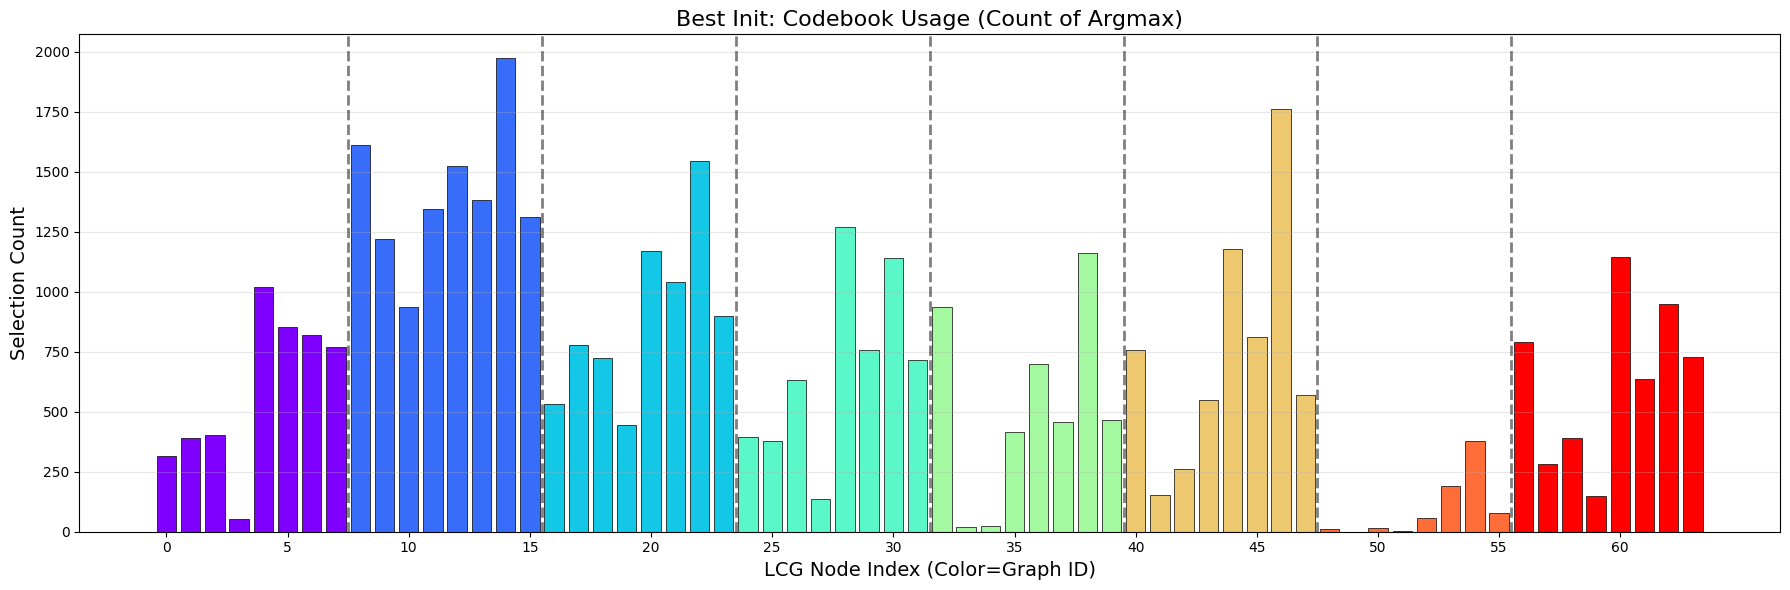


=== Codebook Usage Statistics (Argmax) ===
Total assignments: 44510
LCG 0:  4630 (10.4%)
  → Most used node: 4 (1018 times)
LCG 1: 11303 (25.4%)
  → Most used node: 6 (1974 times)
LCG 2:  7133 (16.0%)
  → Most used node: 6 (1544 times)
LCG 3:  5420 (12.2%)
  → Most used node: 4 (1269 times)
LCG 4:  4176 (9.4%)
  → Most used node: 6 (1161 times)
LCG 5:  6045 (13.6%)
  → Most used node: 6 (1761 times)
LCG 6:   735 (1.7%)
  → Most used node: 6 (376 times)
LCG 7:  5068 (11.4%)
  → Most used node: 4 (1144 times)


In [24]:
# 실행
print("Collecting assignments from all sources...")
assignments, source_labels = collect_all_source_assignments(
    joint_model, loaders, sources, device
)

print(f"Total samples collected: {len(assignments)}")
print(f"Assignment range: [{assignments.min()}, {assignments.max()}]")

# 시각화
plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8)

### Target

In [25]:
# Target 모델 로드
#target_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest3/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251202_182719.pt"
target_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-v5/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251206_203247.pt"
target_ckpt = torch.load(target_ckpt_path, map_location=device)
target_args = target_ckpt['args']

print("=== Target Checkpoint Info ===")
print(f"Epoch: {target_ckpt.get('epoch', 'unknown')}")
print(f"Val AUC: {target_ckpt.get('val_auc', 'unknown')}")
print(f"Threshold: {target_ckpt.get('threshold', 'unknown')}")
print(f"Keys: {list(target_ckpt.keys())}")

# Target 모델 초기화
target_model = Model(
    target_args,
    target_args.input_dim,
    target_args.hidden_dim,
    target_args.output_dim,
    target_args.dropout_rate,
    target_args.llm_model,
    experiment_id="target_viz",
    mode="Few"
).to(device)

target_sd = target_ckpt['model_state_dict']
missing, unexpected = target_model.load_state_dict(target_sd, strict=False)
print("\nTarget Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

target_model.eval()

=== Target Checkpoint Info ===
Epoch: 465
Val AUC: 0.7515542802486849
Threshold: 0.024594614282250404
Keys: ['model_state_dict', 'epoch', 'val_auc', 'val_auc_global', 'threshold', 'args']

Target Model Loaded
Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=64, bias=True)
    (k_proj): Linear(in_features=768, out_features=64, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_la

In [26]:
# Target 데이터 준비 - 간단하게
target_name = target_args.target_data
print(f"\nTarget dataset: {target_name}")

# loaders dict 확인
print(f"Available loaders: {list(loaders.keys())}")

# Target loader 찾기
if target_name in loaders:
    target_loader = loaders[target_name]
    print(f"✓ Found target loader: {target_name}")
else:
    print(f"✗ Target '{target_name}' not in loaders")
    print("Available sources:", list(loaders.keys()))
    # 아무거나 하나 쓰거나 물어보자
    target_loader = list(loaders.values())[0]
    print(f"Using first available loader instead")


Target dataset: heart
Available loaders: ['Heart_disease_statlog', 'Cardiovascular_Disease_Dataset', 'heart_target_3', 'heart_target_4']
✗ Target 'heart' not in loaders
Available sources: ['Heart_disease_statlog', 'Cardiovascular_Disease_Dataset', 'heart_target_3', 'heart_target_4']
Using first available loader instead


In [27]:
# Target 데이터 로드
from dataset.data_dataloaders import prepare_embedding_dataloaders

print(f"\nLoading target dataset: {target_args.target_data}")

r_t = prepare_embedding_dataloaders(target_args, target_args.target_data)
train_loader_t, val_loader_t, test_loader_t = r_t['loaders']
num_classes_t = r_t['num_classes']

print(f"✓ Target loaded")
print(f"  Num classes: {num_classes_t}")

# Test loader 사용
target_loader = test_loader_t
print(f"  Test samples: {len(test_loader_t.dataset)}")
# Target 샘플 수집
print("\nCollecting target samples...")
target_embeddings, target_affinities, target_labels, target_feature_names = collect_all_samples_from_source(
    target_model, target_loader, target_args.target_data
)

print(f"Total collected: {len(target_embeddings)}")
print(f"Label 0: {(np.array(target_labels) == 0).sum()}")
print(f"Label 1: {(np.array(target_labels) == 1).sum()}")


Loading target dataset: heart
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
Training data size: 550
Validation data size: 184
Test data size: 184
✓ Target loaded
  Num classes: 2
  Test samples: 184

Total collected: 184
Label 0: 82
Label 1: 102


In [28]:
# Frobenius distance 계산
print("\nComputing Frobenius distances...")
target_emb_distances, target_aff_distances = compute_frobenius_distances(
    target_embeddings, target_affinities
)


Computing Frobenius distances...


In [29]:
# Reference, Similar, Different 선택
target_ref_idx = 0

target_sim_idx, target_diff_idx = find_most_similar_and_different_by_label(
    target_ref_idx, target_aff_distances, target_labels
)

print(f"\n=== Target Sample Selection ===")
print(f"Reference: idx={target_ref_idx}, label={target_labels[target_ref_idx]}")
print(f"Similar (same label): idx={target_sim_idx}, label={target_labels[target_sim_idx]}")
print(f"  → Affinity Frob: {target_aff_distances[target_ref_idx, target_sim_idx]:.4f}")
print(f"Different (other label): idx={target_diff_idx}, label={target_labels[target_diff_idx]}")
print(f"  → Affinity Frob: {target_aff_distances[target_ref_idx, target_diff_idx]:.4f}")


=== Target Sample Selection ===
Reference: idx=0, label=1
Similar (same label): idx=135, label=1
  → Affinity Frob: 0.0675
Different (other label): idx=58, label=0
  → Affinity Frob: 0.3648



Computing transport plans...

=== Target Pi (Coordinates) ===
Reference: [1.9594929e-03 1.4392280e-11 8.6284233e-03 1.1297027e-02 8.4908336e-02
 1.4402460e-01 6.9905829e-01 5.0123777e-02]
Similar: [1.6321151e-03 2.0837581e-12 7.7274130e-03 7.2006942e-03 6.1132744e-02
 9.2991844e-02 7.9311121e-01 3.6203928e-02]
Different: [2.7553714e-03 4.7721288e-10 1.8437557e-01 4.1763537e-02 3.2978517e-01
 1.6960222e-01 1.7466718e-01 9.7050928e-02]


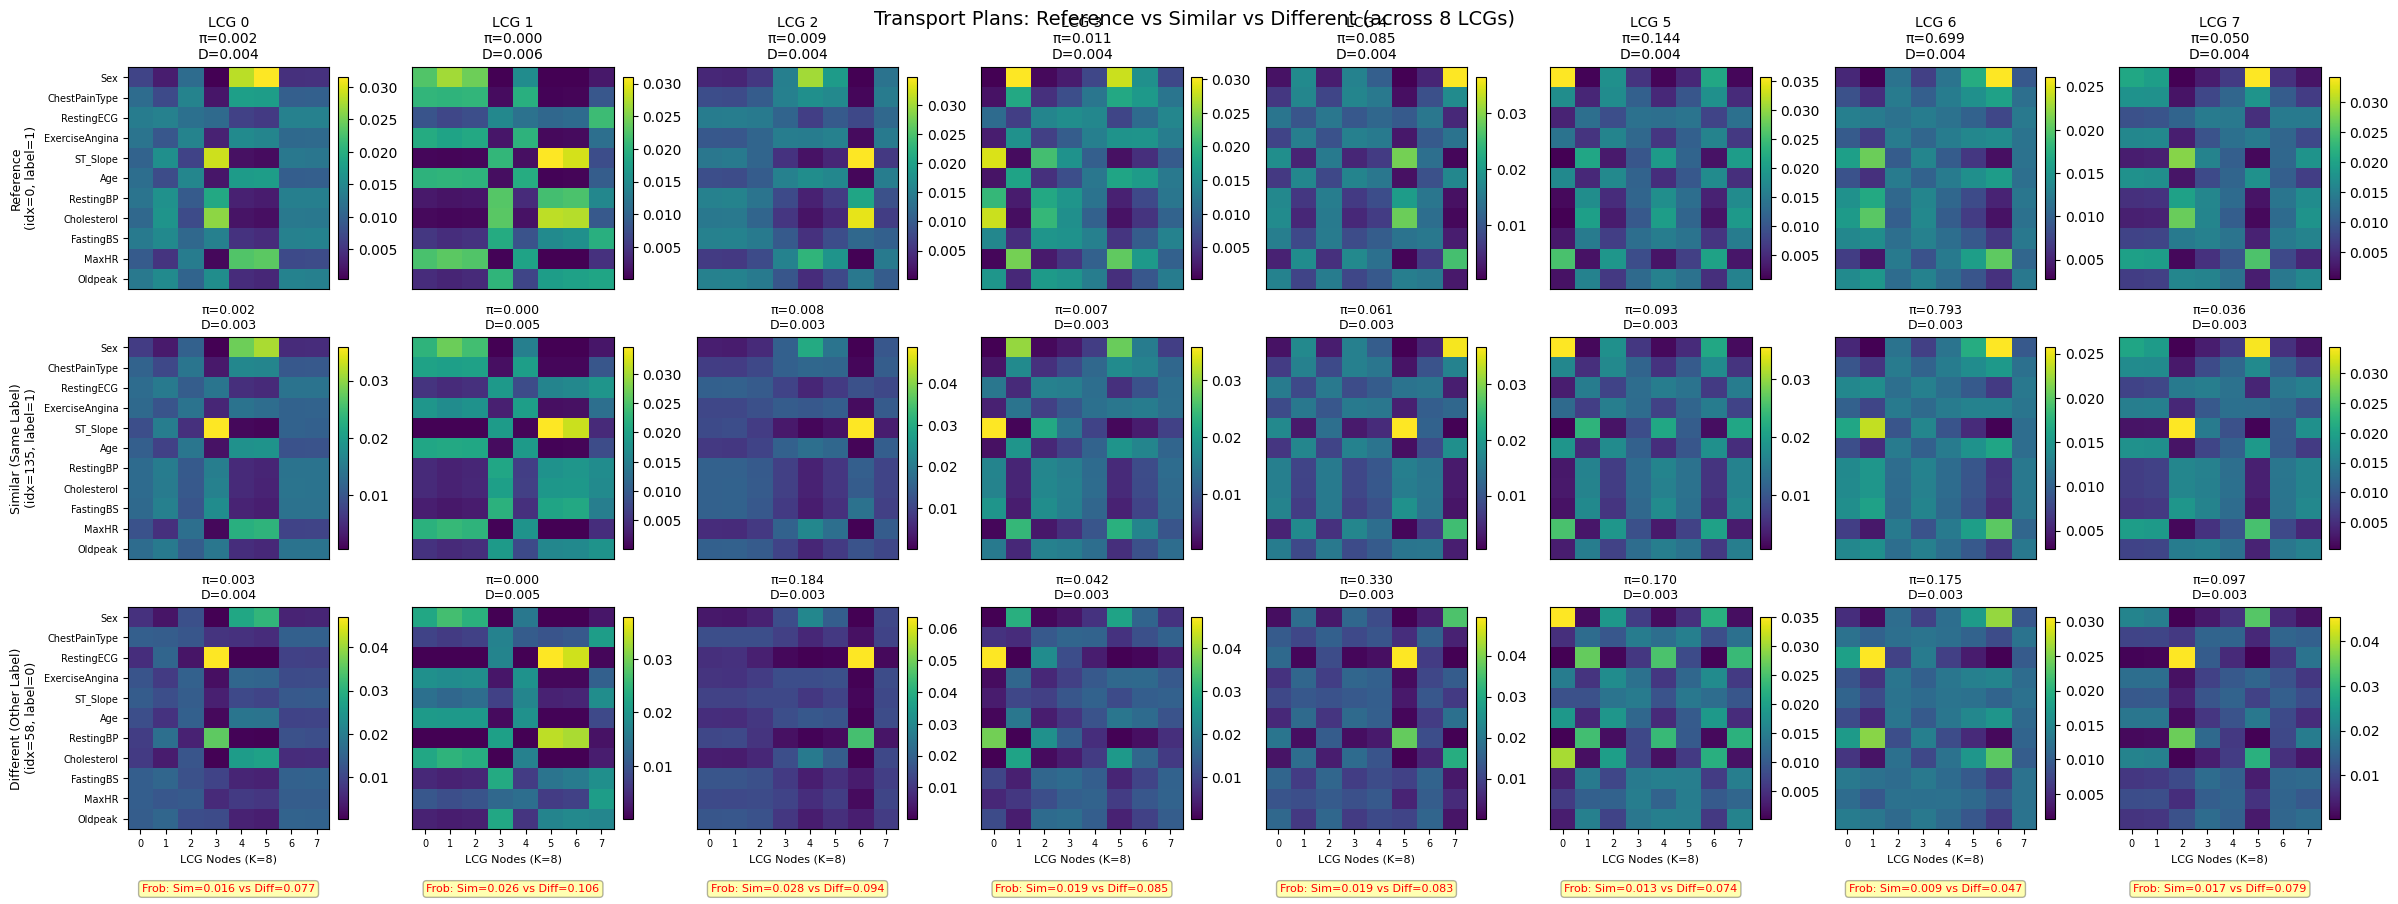

In [30]:
# Transport Plans 계산
print("\nComputing transport plans...")
target_sample_indices = [target_ref_idx, target_sim_idx, target_diff_idx]

target_plans, target_distances, target_coordinates = compute_transport_plans_for_samples(
    target_model, target_sample_indices, target_embeddings, target_affinities
)

print("\n=== Target Pi (Coordinates) ===")
print("Reference:", target_coordinates[0])
print("Similar:", target_coordinates[1])
print("Different:", target_coordinates[2])
# Transport Plans 시각화
plot_transport_plans_grid(
    target_plans, target_coordinates, target_distances,
    target_sample_indices, target_labels, target_feature_names[0]
)

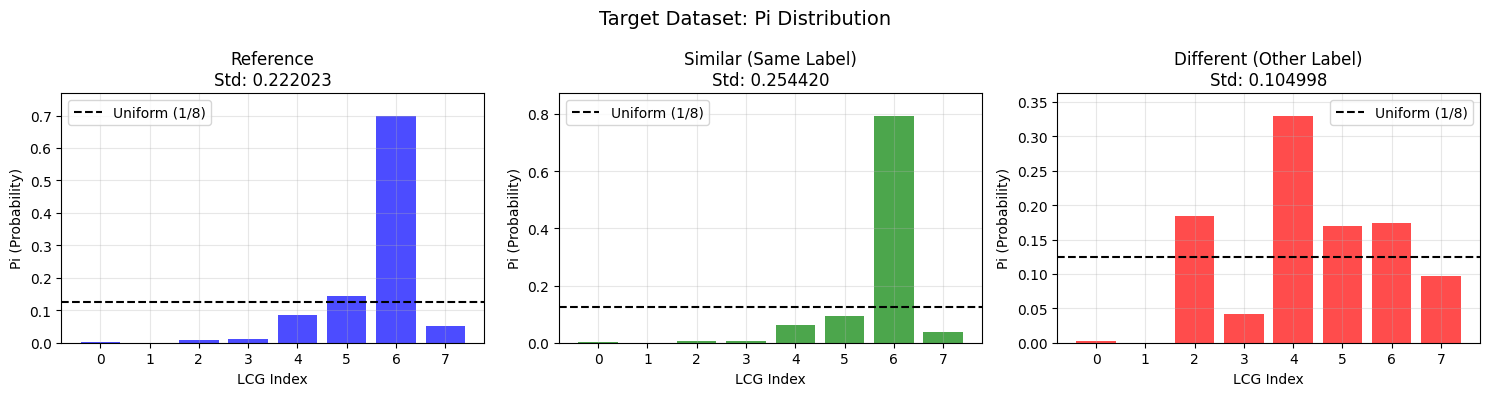

In [31]:
# Pi 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(target_coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Target Dataset: Pi Distribution', fontsize=14)
plt.tight_layout()
plt.show()

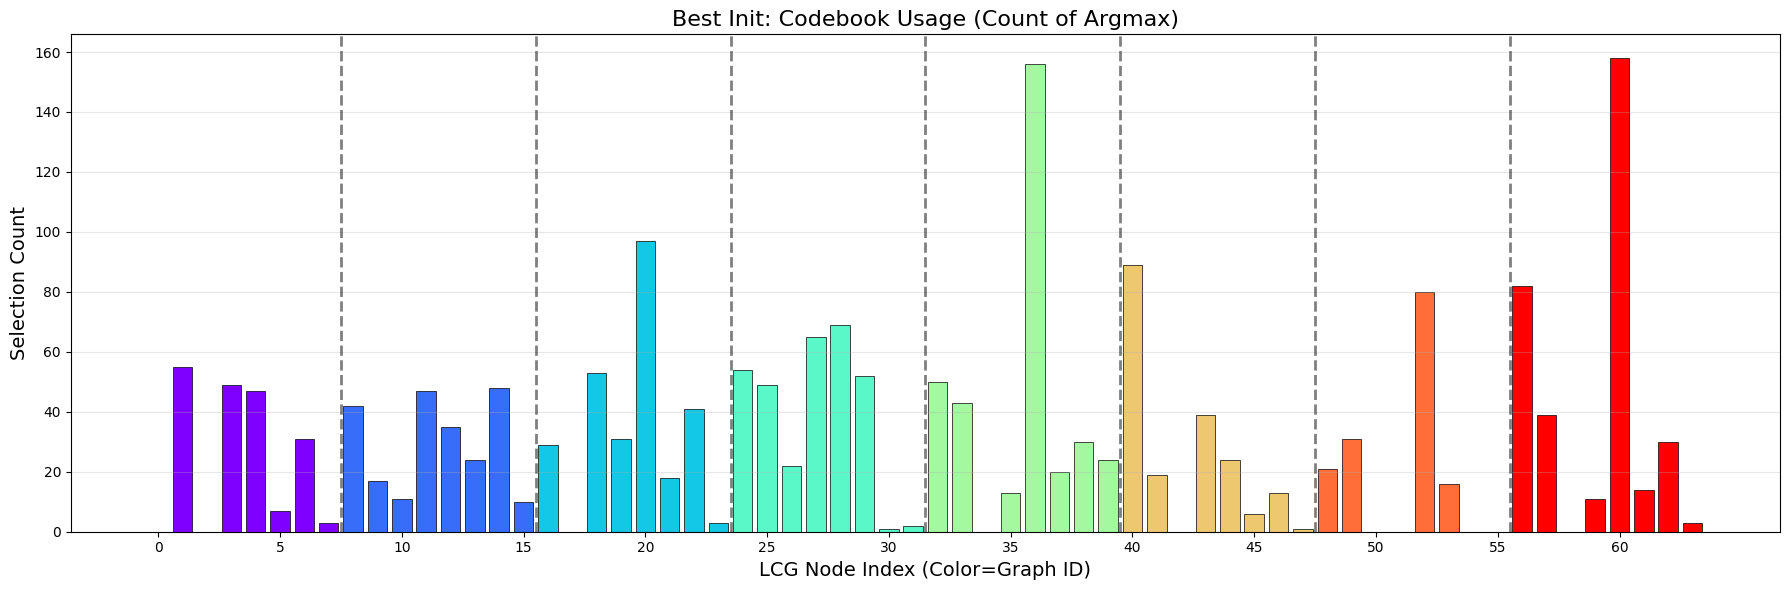


=== Codebook Usage Statistics (Argmax) ===
Total assignments: 2024
LCG 0:   192 (9.5%)
  → Most used node: 1 (55 times)
LCG 1:   234 (11.6%)
  → Most used node: 6 (48 times)
LCG 2:   272 (13.4%)
  → Most used node: 4 (97 times)
LCG 3:   314 (15.5%)
  → Most used node: 4 (69 times)
LCG 4:   336 (16.6%)
  → Most used node: 4 (156 times)
LCG 5:   191 (9.4%)
  → Most used node: 0 (89 times)
LCG 6:   148 (7.3%)
  → Most used node: 4 (80 times)
LCG 7:   337 (16.7%)
  → Most used node: 4 (158 times)


In [32]:
# Codebook Usage (Argmax)
print("\nCollecting codebook usage for target...")
target_assignments, target_source_labels = collect_all_source_assignments(
    target_model, {target_args.target_data: target_loader}, 
    [target_args.target_data], device
)

plot_codebook_usage_argmax(
    target_assignments, target_source_labels, 
    [target_args.target_data], M=8, K=8
)

In [33]:
@torch.no_grad()
def collect_all_cls_embeddings(model, loaders, device):
    """
    모든 loader의 CLS embeddings 수집
    
    Returns:
        cls_embeddings: [N_total, D] - 모든 CLS embeddings
    """
    all_cls_tokens = []
    model.eval()
    
    for src_name, loader in loaders.items():
        print(f"   - Collecting CLS from: {src_name}")
        for batch in loader:
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                    for k, v in batch.items()}
            
            # name/value embeddings
            name_embs, val_embs = [], []
            if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
            if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
            if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
            if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
            
            if not name_embs: continue
            
            name = torch.cat(name_embs, dim=1)
            val = torch.cat(val_embs, dim=1)
            
            # CLS + value
            x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
            
            # GAT forward
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, _ = model.basis_layers[l](name, norm_x)
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
            
            # CLS token
            cls_token = x_basis[:, 0, :].cpu().numpy()
            all_cls_tokens.append(cls_token)
    
    return np.concatenate(all_cls_tokens, axis=0)

In [34]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

def compare_kmeans_clustering(cls_hier, cls_rr, n_clusters=8):
    """
    Hierarchical vs Round Robin의 CLS clustering 비교
    """
    print("="*80)
    print("K-Means Clustering Comparison: Hierarchical vs Round Robin")
    print("="*80)
    
    # K-Means 수행
    print(f"\nPerforming K-Means (n_clusters={n_clusters})...")
    kmeans_hier = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_rr = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    
    cluster_hier = kmeans_hier.fit_predict(cls_hier)
    cluster_rr = kmeans_rr.fit_predict(cls_rr)
    
    # Metrics 계산
    sil_hier = silhouette_score(cls_hier, cluster_hier)
    sil_rr = silhouette_score(cls_rr, cluster_rr)
    
    db_hier = davies_bouldin_score(cls_hier, cluster_hier)
    db_rr = davies_bouldin_score(cls_rr, cluster_rr)
    
    print(f"\n{'Metric':<30} {'Hierarchical':>15} {'Round Robin':>15} {'Winner':>15}")
    print("-"*80)
    print(f"{'Silhouette Score (↑)':<30} {sil_hier:>15.4f} {sil_rr:>15.4f} {'Hier' if sil_hier > sil_rr else 'RR':>15}")
    print(f"{'Davies-Bouldin (↓)':<30} {db_hier:>15.4f} {db_rr:>15.4f} {'Hier' if db_hier < db_rr else 'RR':>15}")
    
    # Cluster size 분포
    print(f"\n{'Cluster Size Distribution':<30} {'Hierarchical':>15} {'Round Robin':>15}")
    print("-"*80)
    for i in range(n_clusters):
        count_hier = (cluster_hier == i).sum()
        count_rr = (cluster_rr == i).sum()
        print(f"Cluster {i:<23} {count_hier:>15d} {count_rr:>15d}")
    
    # PCA 2D 시각화
    print("\nGenerating visualizations...")
    pca = PCA(n_components=2, random_state=42)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Hierarchical
    cls_hier_2d = pca.fit_transform(cls_hier)
    ax = axes[0]
    scatter = ax.scatter(cls_hier_2d[:, 0], cls_hier_2d[:, 1], 
                        c=cluster_hier, cmap='tab10', s=20, alpha=0.6, edgecolors='none')
    
    # Centroids
    centroids_hier_2d = pca.transform(kmeans_hier.cluster_centers_)
    ax.scatter(centroids_hier_2d[:, 0], centroids_hier_2d[:, 1],
              c='red', marker='*', s=500, edgecolors='black', linewidths=2, label='Centroids')
    
    ax.set_title(f'Hierarchical: K-Means Clusters\nSilhouette: {sil_hier:.4f} | Davies-Bouldin: {db_hier:.4f}', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster ID')
    
    # Round Robin
    cls_rr_2d = pca.fit_transform(cls_rr)
    ax = axes[1]
    scatter = ax.scatter(cls_rr_2d[:, 0], cls_rr_2d[:, 1],
                        c=cluster_rr, cmap='tab10', s=20, alpha=0.6, edgecolors='none')
    
    # Centroids
    centroids_rr_2d = pca.transform(kmeans_rr.cluster_centers_)
    ax.scatter(centroids_rr_2d[:, 0], centroids_rr_2d[:, 1],
              c='red', marker='*', s=500, edgecolors='black', linewidths=2, label='Centroids')
    
    ax.set_title(f'Round Robin: K-Means Clusters\nSilhouette: {sil_rr:.4f} | Davies-Bouldin: {db_rr:.4f}', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster ID')
    
    plt.tight_layout()
    plt.show()
    
    return cluster_hier, cluster_rr

In [35]:
# # Hierarchical 모델 CLS 수집
# print("="*80)
# print("Loading Hierarchical Model...")
# print("="*80)

# hier_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251202_170233.pt"

# hier_ckpt = torch.load(hier_ckpt_path, map_location=device)
# hier_model = Model(
#     hier_ckpt['args'],
#     hier_ckpt['args'].input_dim,
#     hier_ckpt['args'].hidden_dim,
#     hier_ckpt['args'].output_dim,
#     hier_ckpt['args'].dropout_rate,
#     hier_ckpt['args'].llm_model,
#     experiment_id="hier_kmeans",
#     mode="Few"
# ).to(device)
# hier_model.load_state_dict(hier_ckpt['model_state_dict'], strict=False)
# hier_model.eval()

# # Sources + Target
# from dataset.data_dataloaders import prepare_embedding_dataloaders
# r_t_hier = prepare_embedding_dataloaders(hier_ckpt['args'], hier_ckpt['args'].target_data)
# target_loader_hier = {hier_ckpt['args'].target_data: r_t_hier['loaders'][2]}

# all_loaders_hier = {**loaders, **target_loader_hier}

# print("\nCollecting CLS from Hierarchical model (Sources + Target)...")
# cls_hier = collect_all_cls_embeddings(hier_model, all_loaders_hier, device)
# print(f"✓ Hierarchical CLS collected: {cls_hier.shape}")

In [36]:
# Round Robin 모델 CLS 수집
print("\n" + "="*80)
print("Loading Round Robin Model...")
print("="*80)

#rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest3/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251202_182719.pt"
rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-v5/42/best.pt"
rr_ckpt = torch.load(rr_ckpt_path, map_location=device)
rr_model = Model(
    rr_ckpt['args'],
    rr_ckpt['args'].input_dim,
    rr_ckpt['args'].hidden_dim,
    rr_ckpt['args'].output_dim,
    rr_ckpt['args'].dropout_rate,
    rr_ckpt['args'].llm_model,
    experiment_id="rr_kmeans",
    mode="Few"
).to(device)
rr_model.load_state_dict(rr_ckpt['model_state_dict'], strict=False)
rr_model.eval()

# Sources + Target
r_t_rr = prepare_embedding_dataloaders(rr_ckpt['args'], rr_ckpt['args'].target_data)
target_loader_rr = {rr_ckpt['args'].target_data: r_t_rr['loaders'][2]}

all_loaders_rr = {**loaders, **target_loader_rr}

print("\nCollecting CLS from Round Robin model (Sources + Target)...")
cls_rr = collect_all_cls_embeddings(rr_model, all_loaders_rr, device)
print(f"✓ Round Robin CLS collected: {cls_rr.shape}")


Loading Round Robin Model...
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
Training data size: 550
Validation data size: 184
Test data size: 184

   - Collecting CLS from: Heart_disease_statlog
   - Collecting CLS from: Cardiovascular_Disease_Dataset
   - Collecting CLS from: heart_target_3
   - Collecting CLS from: heart_target_4
   - Collecting CLS from: heart
✓ Round Robin CLS collected: (3454, 768)


In [37]:
# # K-Means 비교
# cluster_hier, cluster_rr = compare_kmeans_clustering(cls_hier, cls_rr, n_clusters=8)

In [ ]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# import numpy as np

# def visualize_lcg_with_all_data_sidebyside_unified(hier_model, rr_model, loaders, sources, device):
#     """
#     Hierarchical vs Round Robin 나란히 비교 (통일된 PCA)
#     """
#     from dataset.data_dataloaders import prepare_embedding_dataloaders
    
#     # 1. Hierarchical 데이터 수집
#     print("Collecting Hierarchical data...")
#     lcg_hier, _ = hier_model.latent_graph()
#     M, K, D = lcg_hier.shape
#     lcg_hier_nodes = lcg_hier.reshape(M*K, D).detach().cpu().numpy()
#     lcg_hier_labels = np.repeat(range(M), K)
    
#     cls_hier_src, src_hier_labels = collect_cls_by_source(hier_model, loaders, sources, device)
    
#     r_t_hier = prepare_embedding_dataloaders(hier_model.args, hier_model.args.target_data)
#     target_loader_hier = {hier_model.args.target_data: r_t_hier['loaders'][2]}
#     cls_hier_tgt, _ = collect_cls_by_source(hier_model, target_loader_hier, [hier_model.args.target_data], device)
    
#     # 2. Round Robin 데이터 수집
#     print("Collecting Round Robin data...")
#     lcg_rr, _ = rr_model.latent_graph()
#     lcg_rr_nodes = lcg_rr.reshape(M*K, D).detach().cpu().numpy()
#     lcg_rr_labels = np.repeat(range(M), K)
    
#     cls_rr_src, src_rr_labels = collect_cls_by_source(rr_model, loaders, sources, device)
    
#     r_t_rr = prepare_embedding_dataloaders(rr_model.args, rr_model.args.target_data)
#     target_loader_rr = {rr_model.args.target_data: r_t_rr['loaders'][2]}
#     cls_rr_tgt, _ = collect_cls_by_source(rr_model, target_loader_rr, [rr_model.args.target_data], device)
    
#     # 3. 통일된 PCA (모든 데이터 합쳐서)
#     print("Performing unified PCA...")
#     pca = PCA(n_components=2, random_state=42)
    
#     # Hierarchical: 모든 데이터 합치기
#     all_hier_data = np.vstack([cls_hier_src, cls_hier_tgt, lcg_hier_nodes])
#     all_hier_2d = pca.fit_transform(all_hier_data)
    
#     cls_hier_src_2d = all_hier_2d[:len(cls_hier_src)]
#     cls_hier_tgt_2d = all_hier_2d[len(cls_hier_src):len(cls_hier_src)+len(cls_hier_tgt)]
#     lcg_hier_2d = all_hier_2d[len(cls_hier_src)+len(cls_hier_tgt):]
    
#     # Round Robin: 같은 PCA transform 적용
#     all_rr_data = np.vstack([cls_rr_src, cls_rr_tgt, lcg_rr_nodes])
#     all_rr_2d = pca.transform(all_rr_data)  # fit 말고 transform!
    
#     cls_rr_src_2d = all_rr_2d[:len(cls_rr_src)]
#     cls_rr_tgt_2d = all_rr_2d[len(cls_rr_src):len(cls_rr_src)+len(cls_rr_tgt)]
#     lcg_rr_2d = all_rr_2d[len(cls_rr_src)+len(cls_rr_tgt):]
    
#     # 4. 시각화
#     fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    
#     # Source 색상 (중간 진하기)
#     source_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
#     source_names_short = ['Heart_stat', 'Cardio_Dise', 'heart_t3', 'heart_t4']
    
#     # Target 색상
#     target_color = '#9D4EDD'
    
#     # LCG 색상
#     lcg_colors = plt.cm.rainbow(np.linspace(0, 1, M))
    
#     # --- Hierarchical ---
#     ax = axes[0]
    
#     # Sources (중간 진하기)
#     for src_idx in range(len(sources)):
#         mask = (src_hier_labels == src_idx)
#         ax.scatter(cls_hier_src_2d[mask, 0], cls_hier_src_2d[mask, 1],
#                   c=source_colors[src_idx], s=25, alpha=0.6,
#                   label=f'Src: {source_names_short[src_idx]}', edgecolors='none')
    
#     # Target
#     ax.scatter(cls_hier_tgt_2d[:, 0], cls_hier_tgt_2d[:, 1],
#               c=target_color, s=35, alpha=0.7, marker='^',
#               label='Target: heart', edgecolors='black', linewidths=0.5)
    
#     # LCG nodes
#     for m in range(M):
#         mask = (lcg_hier_labels == m)
#         nodes_m = lcg_hier_2d[mask]
        
#         ax.scatter(nodes_m[:, 0], nodes_m[:, 1],
#                   c=[lcg_colors[m]], s=120, marker='D',
#                   edgecolors='black', linewidths=1.5,
#                   label=f'LCG {m}', alpha=0.95, zorder=10)
    
#     ax.set_title('Hierarchical: LCG + Sources + Target',
#                 fontsize=18, fontweight='bold', pad=20)
#     ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=14)
#     ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=14)
#     ax.grid(True, alpha=0.3)
#     ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center',
#              fontsize=10, ncol=7, frameon=True, shadow=True)
    
#     # --- Round Robin ---
#     ax = axes[1]
    
#     # Sources (중간 진하기)
#     for src_idx in range(len(sources)):
#         mask = (src_rr_labels == src_idx)
#         ax.scatter(cls_rr_src_2d[mask, 0], cls_rr_src_2d[mask, 1],
#                   c=source_colors[src_idx], s=25, alpha=0.6,
#                   label=f'Src: {source_names_short[src_idx]}', edgecolors='none')
    
#     # Target
#     ax.scatter(cls_rr_tgt_2d[:, 0], cls_rr_tgt_2d[:, 1],
#               c=target_color, s=35, alpha=0.7, marker='^',
#               label='Target: heart', edgecolors='black', linewidths=0.5)
    
#     # LCG nodes
#     for m in range(M):
#         mask = (lcg_rr_labels == m)
#         nodes_m = lcg_rr_2d[mask]
        
#         ax.scatter(nodes_m[:, 0], nodes_m[:, 1],
#                   c=[lcg_colors[m]], s=120, marker='D',
#                   edgecolors='black', linewidths=1.5,
#                   label=f'LCG {m}', alpha=0.95, zorder=10)
    
#     ax.set_title('Round Robin: LCG + Sources + Target',
#                 fontsize=18, fontweight='bold', pad=20)
#     ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=14)
#     ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=14)
#     ax.grid(True, alpha=0.3)
#     ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center',
#              fontsize=10, ncol=7, frameon=True, shadow=True)
    
#     plt.tight_layout()
#     plt.subplots_adjust(bottom=0.13)
#     plt.show()
    
#     # 통계
#     print(f"\n{'='*80}")
#     print("Data Statistics")
#     print(f"{'='*80}")
#     print(f"Sources:")
#     for src_idx, src_name in enumerate(sources):
#         count = (src_hier_labels == src_idx).sum()
#         print(f"  {src_name}: {count} samples")
#     print(f"\nTarget (Hier): {len(cls_hier_tgt)} samples")
#     print(f"Target (RR): {len(cls_rr_tgt)} samples")
#     print(f"\nLCG: M={M}, K={K}, Total nodes={M*K}")


# def collect_cls_by_source(model, loaders, sources, device):
#     """CLS 수집"""
#     all_cls = []
#     source_labels = []
    
#     model.eval()
#     with torch.no_grad():
#         for src_idx, src_name in enumerate(sources):
#             loader = loaders[src_name]
            
#             for batch in loader:
#                 batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
#                         for k, v in batch.items()}
                
#                 name_embs, val_embs = [], []
#                 if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
#                 if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
#                 if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
#                 if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
#                 if not name_embs: continue
                
#                 name = torch.cat(name_embs, dim=1)
#                 val = torch.cat(val_embs, dim=1)
                
#                 x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                
#                 for l in range(model.num_basis_layers):
#                     norm_x = model.basis_layer_norms[l](x_basis)
#                     basis_outputs, _ = model.basis_layers[l](name, norm_x)
#                     x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
#                 cls_token = x_basis[:, 0, :].cpu().numpy()
#                 all_cls.append(cls_token)
#                 source_labels.extend([src_idx] * cls_token.shape[0])
    
#     return np.vstack(all_cls), np.array(source_labels)

Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
Training data size: 550
Validation data size: 184
Test data size: 184
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
Training data size: 550
Validation data size: 184
Test data size: 184
Performing unified PCA...


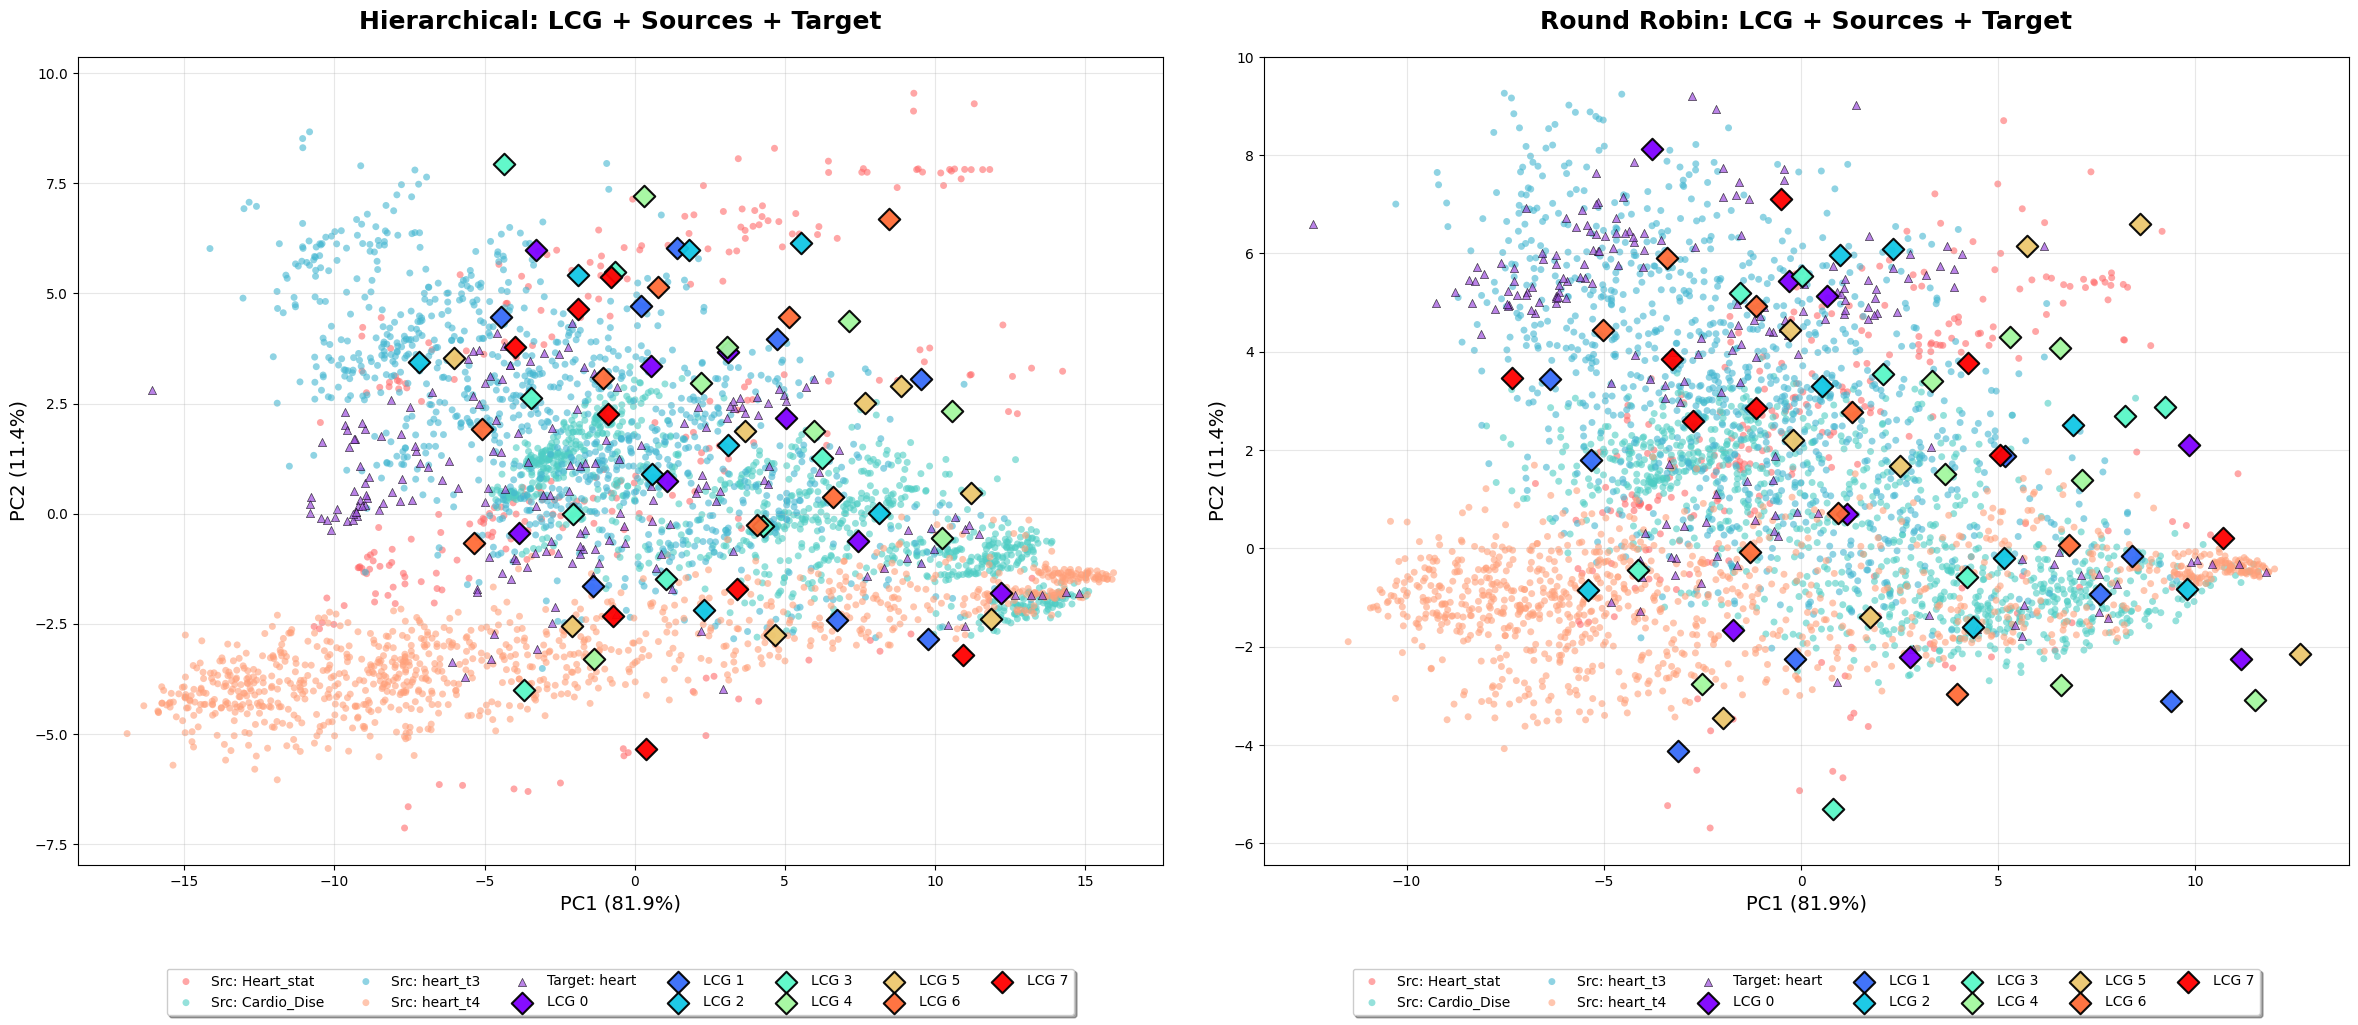


Data Statistics
Sources:
  Heart_disease_statlog: 270 samples
  Cardiovascular_Disease_Dataset: 1000 samples
  heart_target_3: 1000 samples
  heart_target_4: 1000 samples

Target (Hier): 184 samples
Target (RR): 184 samples

LCG: M=8, K=8, Total nodes=64


In [ ]:
# # 실행
# visualize_lcg_with_all_data_sidebyside_unified(hier_model, rr_model, loaders, sources, device)

## Gradient Check

In [1]:
import sys
import os
import time
import logging
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
import math
import copy
import pickle
import random
import warnings
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as nn_init
import torch.optim as optim
from torch import Tensor
from torch.utils.data import DataLoader, ConcatDataset

# Sklearn
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# System Path (사용자 환경)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

# Custom Modules
from models.TabularFLM_S import Model
from models.coordinate import CoordinatorMLP 
from models.LCG import LatentCompositeGraph, GraphQuantizer 
from models.LCGGNN import LatentCompositeGNN
from models.BasisGraphAttention import BasisGATLayer_MUL, BasisGATLayer_IND
from utils.util import fix_seed, make_warmup_cosine_epochs, format_time

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f">>> Device: {device}")

# =============================================================================
# [User Provided] Data Loading Functions
# =============================================================================
def prepare_embedding_dataloaders(args, dataset_name):
    """저장된 embedding 데이터를 로드하고 train/val/test로 분할한 뒤 DataLoader로 변환"""
    
    torch.manual_seed(args.random_seed)
    np.random.seed(args.random_seed)
    random.seed(args.random_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(args.random_seed)
        torch.cuda.manual_seed_all(args.random_seed)
    torch.backends.cudnn.benchmark = True
    
    # 파일 경로 설정
    base_path = "/storage/personal/eungyeop/dataset/embedding"
    if args.embed_type == "_":
        sub_dir = f"tabular_embeddings_/{args.llm_model}"
    else:
        sub_dir = f"tabular_embeddings_{args.embed_type}/{args.llm_model}"
    emb_name =  f"embedding_{dataset_name}.pkl"
    file_path = os.path.join(base_path, sub_dir, emb_name)
    
    print(f"Loading embeddings from: {file_path}")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    # 데이터 로드
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    
    embeddings = data['embeddings']
    labels = [emb['y'].item() for emb in embeddings]
    num_classes = data['num_classes']
    
    if dataset_name == "heart_disease_clean":
        print("Using custom sampling : 100 random samples (60/20/20 split)")
        total_indices = np.arange(len(embeddings))
        np.random.shuffle(total_indices)
        selected_indices = total_indices[:100]
        embeddings = [embeddings[i] for i in selected_indices]
        labels = [labels[i] for i in selected_indices]
        
    # Train/Val/Test Split (60/20/20)
    indices = list(range(len(embeddings)))
    train_val_idx, test_idx = train_test_split(
        indices, test_size=0.2,
        stratify=labels,
        random_state=args.random_seed
    )
    
    train_val_embeddings = [embeddings[i] for i in train_val_idx]
    train_val_labels = [labels[i] for i in train_val_idx]
    
    train_idx, val_idx = train_test_split(
        list(range(len(train_val_embeddings))),
        test_size=0.25,
        stratify=train_val_labels,
        random_state=args.random_seed
    )
    
    # Split datasets
    train_dataset = [train_val_embeddings[i] for i in train_idx]
    val_dataset = [train_val_embeddings[i] for i in val_idx]
    test_dataset = [embeddings[i] for i in test_idx]
    
    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False)
    
    print(f"Training data size: {len(train_dataset)}")
    print(f"Validation data size: {len(val_dataset)}")
    print(f"Test data size: {len(test_dataset)}")
    
    return {
        'loaders': (train_loader, val_loader, test_loader),
        'num_classes': num_classes
    }

def get_few_shot_embedding_samples(train_loader, args):
   """train_loader에서 embedding data의 few-shot 샘플링을 수행 (표준 K-shot)"""
   np.random.seed(args.random_seed)
   dataset = train_loader.dataset
   labels = [data['y'].item() for data in dataset]
   num_classes = len(set(labels))
   
   shot_per_class = args.few_shot 
   
   support_data = []
   for cls in range(num_classes):
       cls_data = [data for data in dataset if data['y'].item() == cls]
       if len(cls_data) < shot_per_class:
           warnings.warn(f"Class {cls} has fewer samples ({len(cls_data)}) than required ({shot_per_class}). Using replacement sampling.")
           selected = random.choices(cls_data, k=shot_per_class)
       else:
           selected = random.sample(cls_data, k=shot_per_class)
       support_data.extend(selected)
   
   return DataLoader(support_data, batch_size=args.batch_size, shuffle=True)

>>> Device: cuda


In [4]:
# =============================================================================
# 2-1. [Robust Training Functions] 데이터셋 길이에 의존하지 않는 안전한 학습 함수
# =============================================================================
def binary_train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for batch in train_loader:
        optimizer.zero_grad()
        if isinstance(batch, dict):
            y = batch['y'].to(device)
            loss = model(batch, y) # Forward returns loss
        else:
            x, y = batch; x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch['y']) if isinstance(batch, dict) else loss.item() * len(y)
        total_samples += len(batch['y']) if isinstance(batch, dict) else len(y)
    return total_loss / max(total_samples, 1)

def multi_train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for batch in train_loader:
        optimizer.zero_grad()
        if isinstance(batch, dict):
            y = batch['y'].to(device).long()
            loss = model(batch, y)
        else:
            x, y = batch; x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch['y']) if isinstance(batch, dict) else loss.item() * len(y)
        total_samples += len(batch['y']) if isinstance(batch, dict) else len(y)
    return total_loss / max(total_samples, 1)

def binary_evaluate(model, loader, criterion, device):
    model.eval()
    loss_g_sum, loss_l_sum, dataset_len = 0.0, 0.0, 0
    y_true, y_pred_g, y_pred_l = [], [], []
    has_global = False
    
    with torch.no_grad():
        for batch in loader:
            preds = model.predict(batch, return_all=True)
            target = batch['y'].to(device).view(-1, 1).float()
            
            if isinstance(preds, tuple) and len(preds) == 2:
                global_pred, local_pred = preds
                has_global = True
                loss_g = criterion(global_pred, target)
                loss_g_sum += loss_g.item() * len(target)
                y_pred_g.extend(torch.sigmoid(global_pred).cpu().numpy())
            else:
                local_pred = preds
            
            loss_l = criterion(local_pred, target)
            loss_l_sum += loss_l.item() * len(target)
            y_pred_l.extend(torch.sigmoid(local_pred).cpu().numpy())
            y_true.extend(target.cpu().numpy())
            dataset_len += len(target)
            
    loss_l_avg = loss_l_sum / max(dataset_len, 1)
    res_l = (loss_l_avg, np.array(y_true), np.array(y_pred_l))
    
    if has_global:
        loss_g_avg = loss_g_sum / max(dataset_len, 1)
        res_g = (loss_g_avg, np.array(y_true), np.array(y_pred_g))
    else:
        res_g = res_l
    return res_g, res_l

def multi_evaluate(model, loader, criterion, device):
    # (Multi-class도 유사하게 구현 필요, Binary가 메인이므로 생략하거나 필요시 추가)
    # 현재 코드에서는 Binary 가정하고 진행
    return binary_evaluate(model, loader, criterion, device)

# =============================================================================
# 2-2. [Step Loader]
# =============================================================================
class MultiSourceStepLoader:
    def __init__(self, loaders, mode='random', seed=42, src_idx=None):
        self.loaders = loaders
        self.mode = mode
        self.rng = np.random.default_rng(seed)
        self.src_idx = src_idx
        self._blens = [len(dl) for dl in loaders]
        self._steps = int(np.sum(self._blens))

    def __len__(self): return self._steps
    def __iter__(self):
        iters = [iter(dl) for dl in self.loaders]
        pos = [0] * len(self.loaders)
        k = len(self.loaders)
        for s in range(self._steps):
            idx = s % k if self.mode == 'round' else int(self.rng.integers(0, k))
            if pos[idx] >= self._blens[idx]:
                iters[idx] = iter(self.loaders[idx]); pos[idx] = 0
            batch = next(iters[idx]); pos[idx] += 1
            batch['src_idx'] = self.src_idx if self.src_idx is not None else idx
            yield batch

def make_step(loaders, mode='random', seed=42): return MultiSourceStepLoader(loaders, mode=mode, seed=seed)

# =============================================================================
# 2-3. [Viz Tools] 시각화 수집기 & 그리기
# =============================================================================
class VizCollector:
    def __init__(self, args, source_names, loaders_list, device, save_interval=20):
        self.args = args; self.save_interval = save_interval; self.device = device
        self.source_names = source_names if isinstance(source_names, (list, tuple)) else [source_names]
        
        self.history = {
            'epochs': [], 'lcg_embeddings': [], 'lcg_affinities': [],
            'sample_pis': {name: [] for name in self.source_names}, 
            'sample_plans': {name: [] for name in self.source_names},
            'grad_norm_pos': [], 'grad_norm_str': [],
            'loss_local': [], 'loss_global': [], 'cost_feat': [], 'cost_struct': [],
            'auc_local_per_source': [], 'auc_global_per_source': [],
            'auc_local_mean': [], 'auc_global_mean': []
        }
        
        self.fixed_batches = {}
        print(f">>> [VizCollector] Registering fixed samples (0~4) for {len(loaders_list)} sources...")
        for i, loader in enumerate(loaders_list):
            src_name = self.source_names[i]
            try:
                batch = next(iter(loader))
                sliced_batch = {}
                for k, v in batch.items():
                    if isinstance(v, torch.Tensor): sliced_batch[k] = v[:5].to(device)
                    else: sliced_batch[k] = v[:5] if hasattr(v, '__getitem__') else v
                sliced_batch['src_idx'] = i
                self.fixed_batches[src_name] = sliced_batch
            except StopIteration: pass

    def step(self, epoch, model, losses=None, aucs=None, costs=None):
        if losses: self.history['loss_local'].append(losses.get('local', 0)); self.history['loss_global'].append(losses.get('global', 0))
        if aucs:
            self.history['auc_local_mean'].append(aucs.get('local_mean', 0))
            self.history['auc_global_mean'].append(aucs.get('global_mean', 0))
            if 'local_per_src' in aucs: self.history['auc_local_per_source'].append(aucs['local_per_src'])
            if 'global_per_src' in aucs: self.history['auc_global_per_source'].append(aucs['global_per_src'])
        if costs: self.history['cost_feat'].append(costs.get('feat', 0)); self.history['cost_struct'].append(costs.get('struct', 0))

        if (epoch + 1) % self.save_interval == 0 or epoch == 0:
            self.history['epochs'].append(epoch + 1)
            if hasattr(model, 'latent_graph'):
                self.history['lcg_embeddings'].append(model.latent_graph.node_embeddings.detach().cpu().numpy())
                self.history['lcg_affinities'].append(model.latent_graph.get_structure().detach().cpu().numpy())
                
                g_pos = model.latent_graph.node_embeddings.grad.norm().item() if model.latent_graph.node_embeddings.grad is not None else 0.0
                self.history['grad_norm_pos'].append(g_pos)
                
                g_str = 0.0
                if hasattr(model.latent_graph, 'adj_param') and model.latent_graph.adj_param.grad is not None:
                    g_str = model.latent_graph.adj_param.grad.norm().item()
                elif hasattr(model.latent_graph, 'q_proj') and model.latent_graph.q_proj.weight.grad is not None:
                    g_str = model.latent_graph.q_proj.weight.grad.norm().item()
                self.history['grad_norm_str'].append(g_str)
            self._track_fixed_samples(model)

    def _track_fixed_samples(self, model):
        was_training = model.training; model.eval()
        with torch.no_grad():
            for src_name, batch in self.fixed_batches.items():
                dummy_y = torch.zeros(len(batch['cat_value_embeddings']), device=self.device)
                _ = model(batch, dummy_y) # Trigger Hook
                if hasattr(model, 'graph_quantizer'):
                    if getattr(model.graph_quantizer, 'last_pi', None) is not None:
                        self.history['sample_pis'][src_name].append(model.graph_quantizer.last_pi.detach().cpu().numpy())
                    if getattr(model.graph_quantizer, 'last_plan', None) is not None:
                        self.history['sample_plans'][src_name].append(model.graph_quantizer.last_plan.detach().cpu().numpy())
        if was_training: model.train()

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np

def plot_training_results(history, n_graphs=8, n_nodes=8):
    epochs = history['epochs']
    if len(epochs) == 0:
        print("No data collected yet.")
        return

    # LCG 고유 색상 (Rainbow)
    colors = cm.rainbow(np.linspace(0, 1, n_graphs))
    
    print(f">>> Plotting results for {len(epochs)} snapshots...")

    # =========================================================
    # 1. [Dynamic] LCG Scatter (t-SNE)
    # =========================================================
    snap_indices = np.linspace(0, len(epochs)-1, min(5, len(epochs)), dtype=int)
    if len(snap_indices) > 0:
        fig, axes = plt.subplots(1, len(snap_indices), figsize=(4 * len(snap_indices), 4))
        if len(snap_indices) == 1: axes = [axes]
        
        for i, idx in enumerate(snap_indices):
            emb = history['lcg_embeddings'][idx].reshape(-1, history['lcg_embeddings'][idx].shape[-1])
            try:
                # Projector 없이 매번 t-SNE
                emb_2d = TSNE(n_components=2, perplexity=min(30, emb.shape[0]-1), random_state=42).fit_transform(emb)
                ax = axes[i]
                for g_id in range(n_graphs):
                    start, end = g_id * n_nodes, (g_id + 1) * n_nodes
                    ax.scatter(emb_2d[start:end, 0], emb_2d[start:end, 1], color=colors[g_id], alpha=0.7, label=f'G{g_id}' if i==0 else "")
                ax.set_title(f"LCG Scatter (Ep {epochs[idx]})")
                if i == 0: ax.legend(fontsize='x-small', loc='upper right')
            except: pass
        plt.tight_layout(); plt.show()

    # =========================================================
    # 2. [Dynamic] Soft Assignment Pi (Bar Chart)
    # =========================================================
    # 첫 번째 Source 기준
    first_src = list(history['sample_pis'].keys())[0]
    if len(history['sample_pis'][first_src]) > 0:
        last_pi = history['sample_pis'][first_src][-1] # [5, M]
        
        fig, axes = plt.subplots(1, 5, figsize=(20, 3))
        fig.suptitle(f"Soft Assignment (Pi) - {first_src} (Ep {epochs[-1]})", fontsize=14)
        for i in range(5):
            axes[i].bar(range(n_graphs), last_pi[i], color=colors, edgecolor='black')
            axes[i].set_ylim(0, 1.0)
            axes[i].set_title(f"Sample {i}")
            axes[i].set_xlabel("LCG Index")
        plt.tight_layout(); plt.show()

    # =========================================================
    # 3. [Detailed] Transport Plan (5 Samples x M Graphs)
    # =========================================================
    # last_plan shape: [5, M, N, K]
    if len(history['sample_plans'][first_src]) > 0:
        last_plan = history['sample_plans'][first_src][-1] 
        
        # 5행(Samples) x M열(LCGs) 그리드 생성
        fig, axes = plt.subplots(5, n_graphs, figsize=(3 * n_graphs, 2.5 * 5))
        fig.suptitle(f"Detailed Transport Plan (Rows=Samples, Cols=LCGs) - {first_src}", fontsize=16, y=1.02)
        
        for s_idx in range(5): # Sample Loop
            for m_idx in range(n_graphs): # LCG Loop
                ax = axes[s_idx, m_idx]
                
                # Plan Matrix: [N(Source), K(LCG)]
                plan_matrix = last_plan[s_idx, m_idx] 
                
                # Heatmap 그리기
                sns.heatmap(plan_matrix, ax=ax, cmap='viridis', cbar=False, xticklabels=False, yticklabels=False)
                
                # 테두리 색상을 LCG 색상으로 (시각적 구분)
                for spine in ax.spines.values():
                    spine.set_edgecolor(colors[m_idx])
                    spine.set_linewidth(2)
                
                # 라벨링 (첫 행/첫 열만)
                if s_idx == 0: ax.set_title(f"LCG {m_idx}", color=colors[m_idx], fontweight='bold')
                if m_idx == 0: ax.set_ylabel(f"Sample {s_idx}\n(Src Nodes)", fontsize=10)
                if s_idx == 4: ax.set_xlabel("LCG Nodes", fontsize=8)
                    
        plt.tight_layout()
        plt.show()

    # =========================================================
    # 4 ~ 7. Metrics (Loss, AUC, Cost)
    # =========================================================
    # Loss
    plt.figure(figsize=(10, 3))
    plt.plot(history['loss_local'], label='Local', color='blue', alpha=0.6)
    plt.plot(history['loss_global'], label='Global', color='red', alpha=0.6)
    plt.title("Loss"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

    # AUCs
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 4))
    
    # Local AUC
    l_aucs = np.array(history['auc_local_per_source'])
    if l_aucs.ndim == 2:
        for i in range(l_aucs.shape[1]):
            c = cm.nipy_spectral(i / max(1, l_aucs.shape[1]-1))
            ax1.plot(l_aucs[:, i], color=c, alpha=0.5, label=f'Src {i}')
    ax1.plot(history['auc_local_mean'], 'k--', linewidth=2, label='Mean')
    ax1.set_title("Local AUC"); ax1.legend()

    # Global AUC
    g_aucs = np.array(history['auc_global_per_source'])
    if g_aucs.ndim == 2:
        for i in range(g_aucs.shape[1]):
            c = cm.nipy_spectral(i / max(1, g_aucs.shape[1]-1))
            ax2.plot(g_aucs[:, i], color=c, alpha=0.5, label=f'Src {i}')
    ax2.plot(history['auc_global_mean'], 'k--', linewidth=2, label='Mean')
    ax2.set_title("Global AUC"); ax2.legend()
    plt.show()

    # Cost
    plt.figure(figsize=(10, 3))
    plt.plot(history['cost_feat'], label='Feature', color='orange')
    plt.plot(history['cost_struct'], label='Struct', color='purple')
    plt.title("FGW Cost"); plt.legend(); plt.show()

    # =========================================================
    # 8. [Static] Total Assignment (Rainbow Bar)
    # =========================================================
    if len(history['sample_plans'][first_src]) > 0:
        # [5, M, N, K] -> [M, K] (Batch & Source Sum) -> [M*K]
        last_plan_sum = history['sample_plans'][first_src][-1].sum(axis=(0, 2)).flatten() 
        node_colors = []
        for i in range(n_graphs):
            for _ in range(n_nodes): node_colors.append(colors[i])
        
        plt.figure(figsize=(15, 4))
        plt.bar(range(len(last_plan_sum)), last_plan_sum, color=node_colors, edgecolor='black', width=0.8)
        plt.title(f"Total LCG Node Selection (Sum over 5 Samples) - {first_src}", fontsize=14)
        for i in range(1, n_graphs): plt.axvline(x=i*n_nodes - 0.5, color='gray', linestyle=':', alpha=0.5)
        plt.show()

    # =========================================================
    # 9. [Static] Affinity Heatmaps
    # =========================================================
    if len(history['lcg_affinities']) > 0:
        last_aff = history['lcg_affinities'][-1]
        cols = 4; rows = (n_graphs + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
        axes = axes.flatten()
        for g_id in range(n_graphs):
            if g_id < len(last_aff):
                sns.heatmap(last_aff[g_id], ax=axes[g_id], cmap='magma', cbar=False, square=True)
                axes[g_id].set_title(f"LCG {g_id}", color=colors[g_id], fontweight='bold')
                for spine in axes[g_id].spines.values(): spine.set_edgecolor(colors[g_id]); spine.set_linewidth(3)
            else: axes[g_id].axis('off')
        plt.tight_layout(); plt.show()

    # =========================================================
    # 10. [Metric] Gradients
    # =========================================================
    plt.figure(figsize=(10, 3))
    plt.plot(history['grad_norm_pos'], label='Pos (Emb)', color='blue')
    plt.plot(history['grad_norm_str'], label='Str (Adj)', color='green')
    plt.title("Gradient Norms (Log Scale)"); plt.yscale('log'); plt.legend(); plt.show()

>>> Loading Checkpoint from: /storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt
>>> Model Loaded (Phase 2).
>>> [Patch] GraphQuantizer hooked.
>>> Loading Sources: ['Heart_disease_statlog', 'Cardiovascular_Disease_Dataset', 'heart_target_3', 'heart_target_4']
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading embeddings from: /storage/personal/e

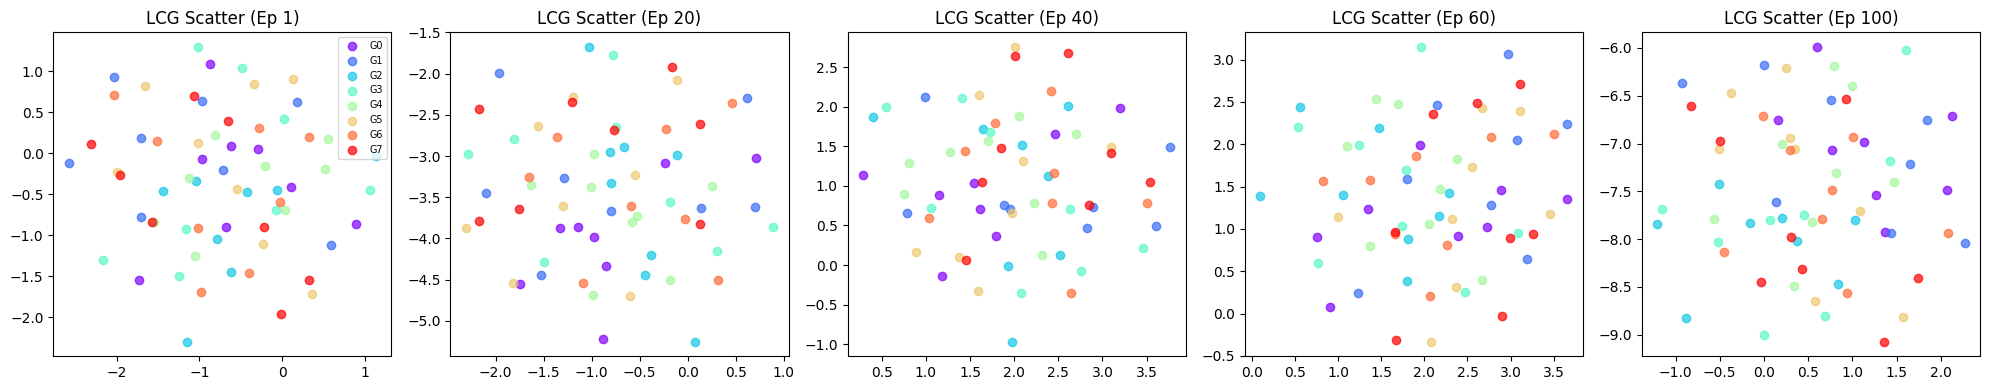

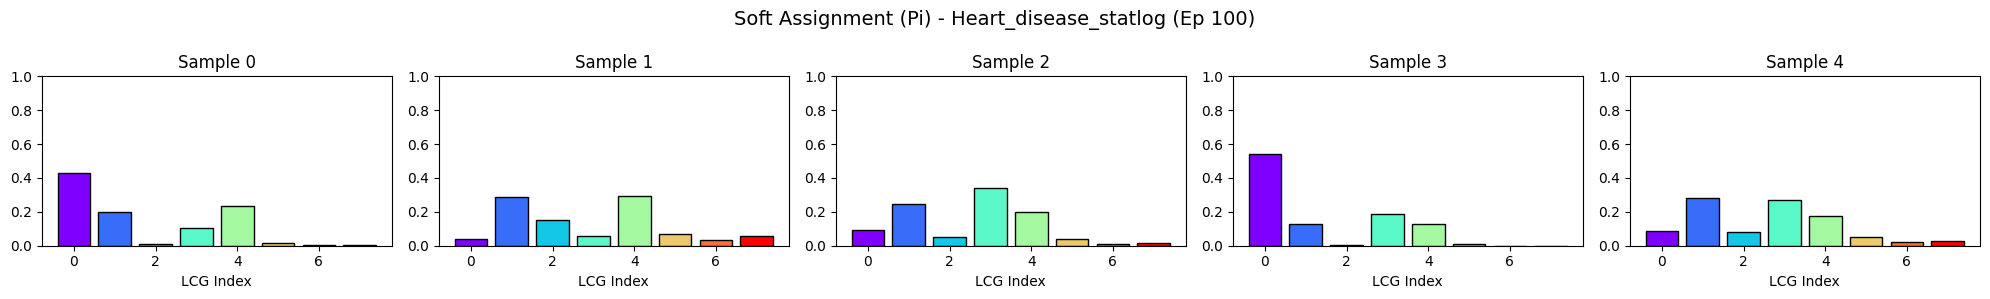

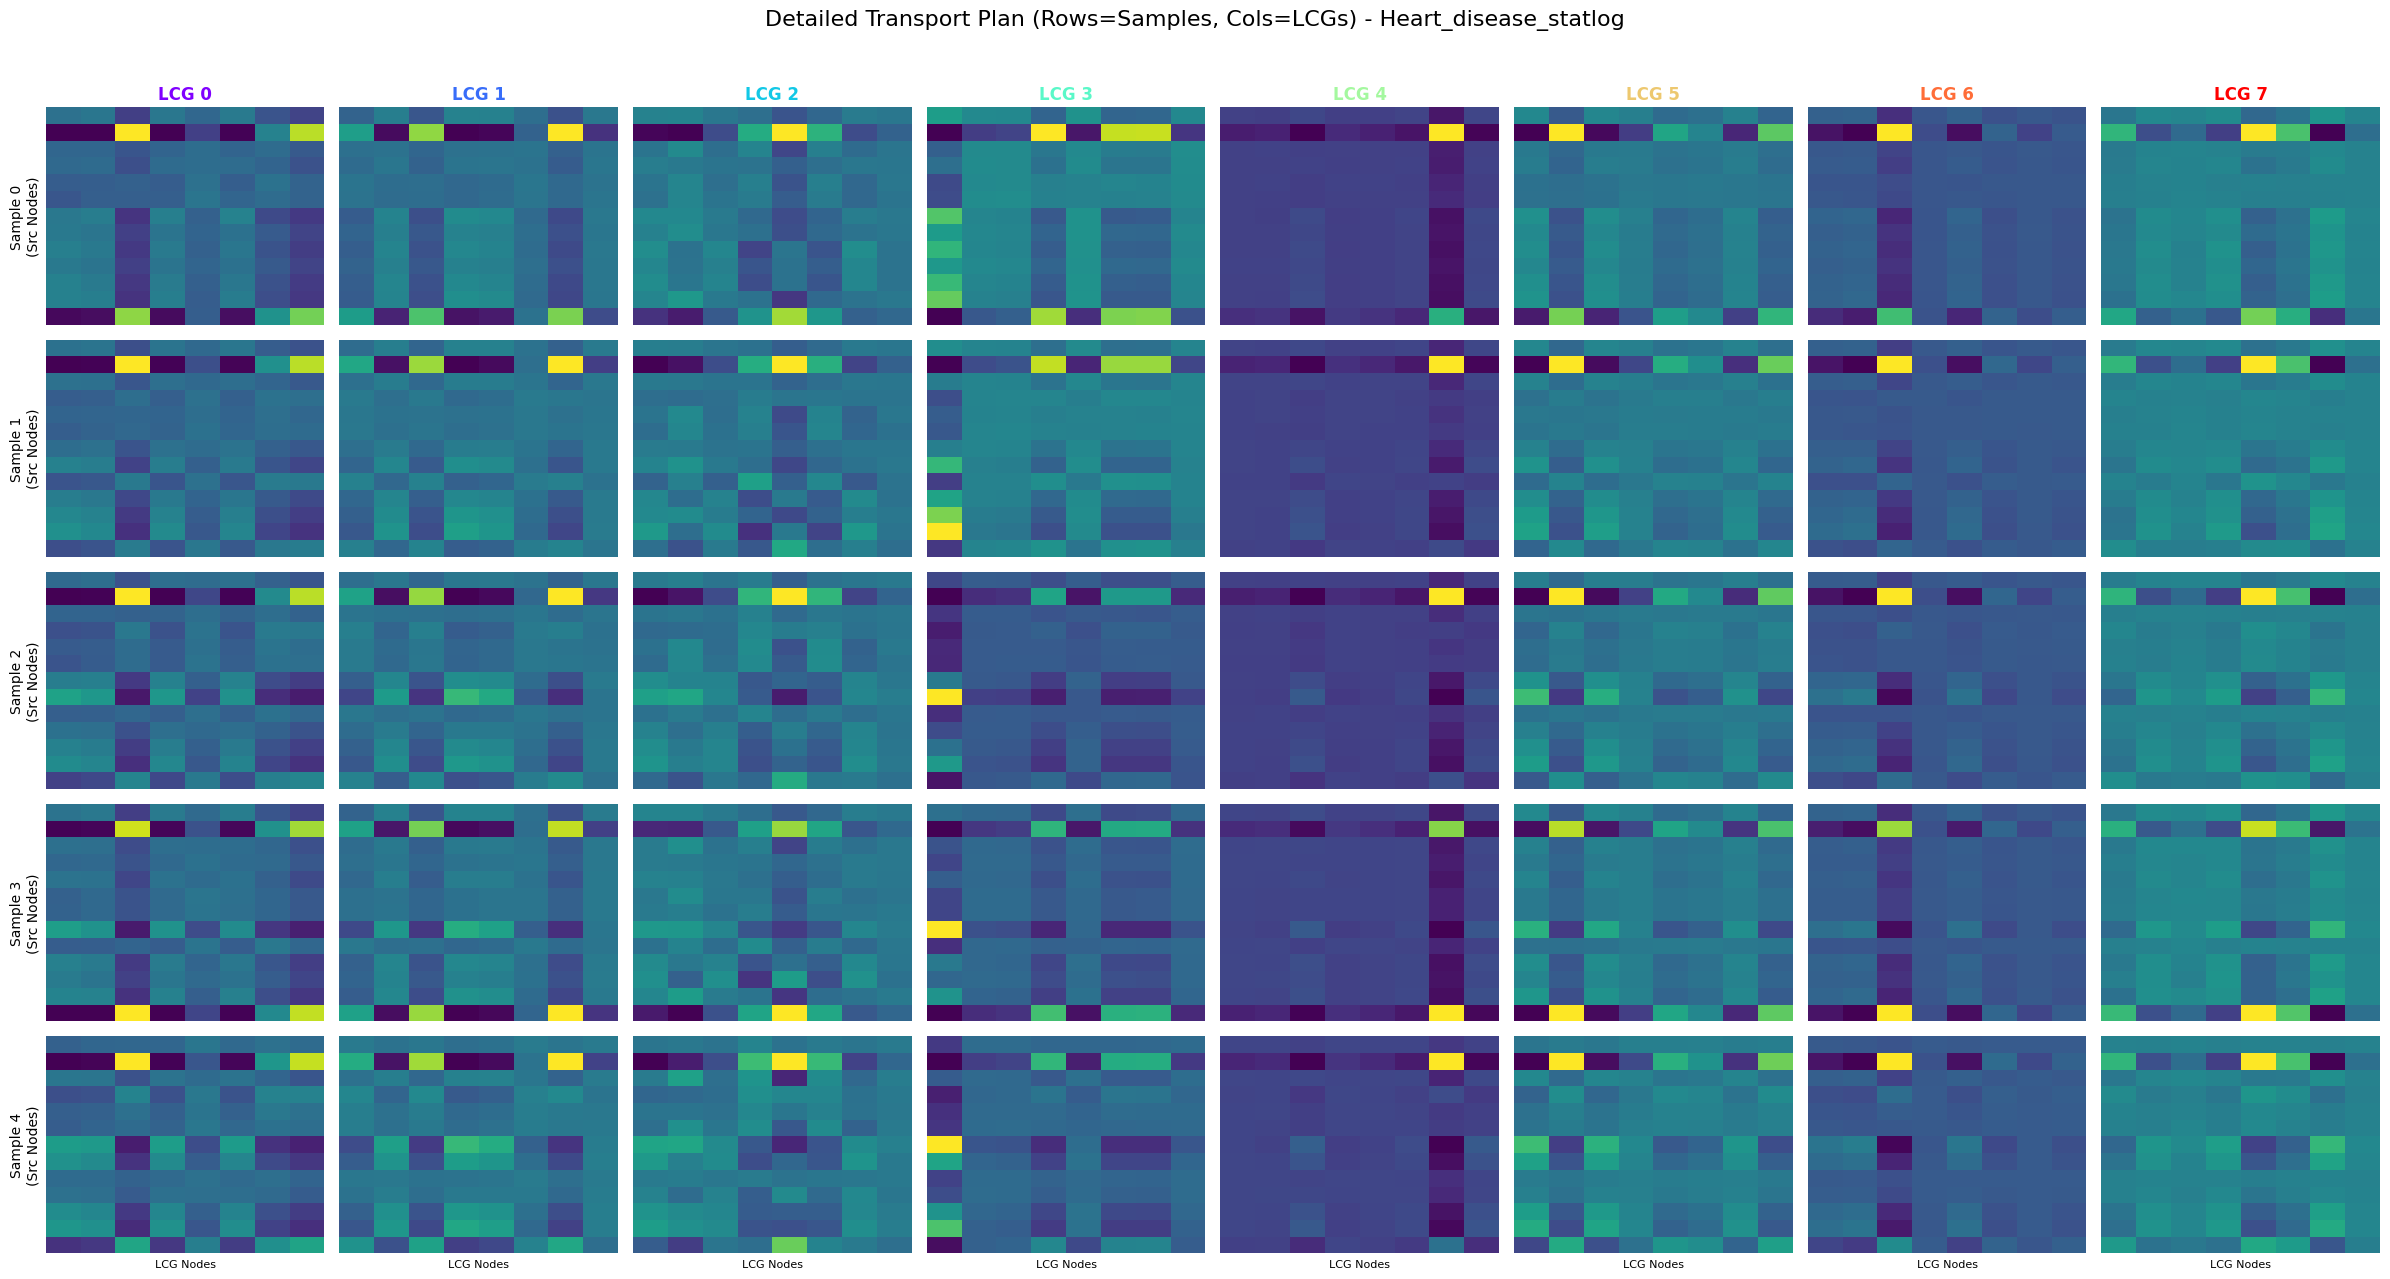

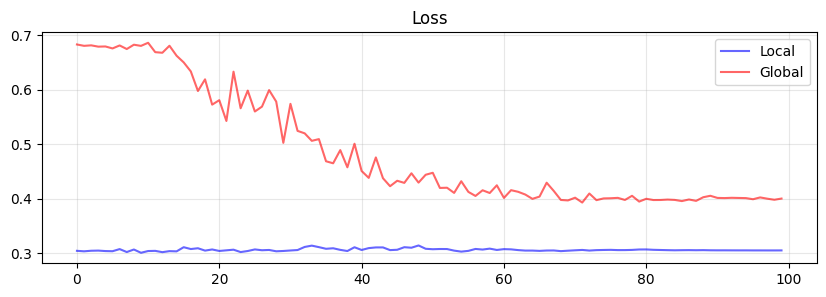

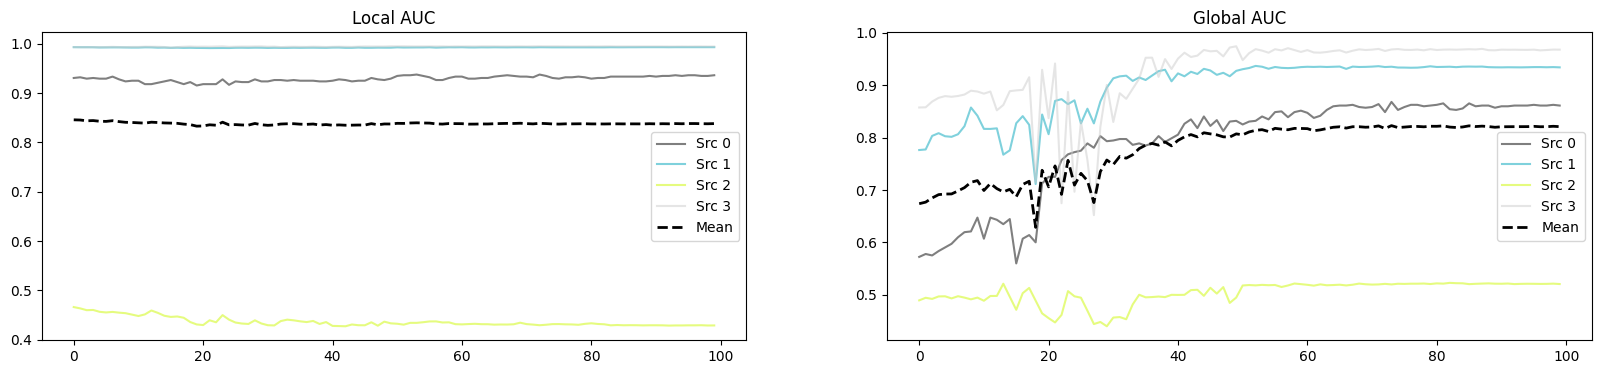

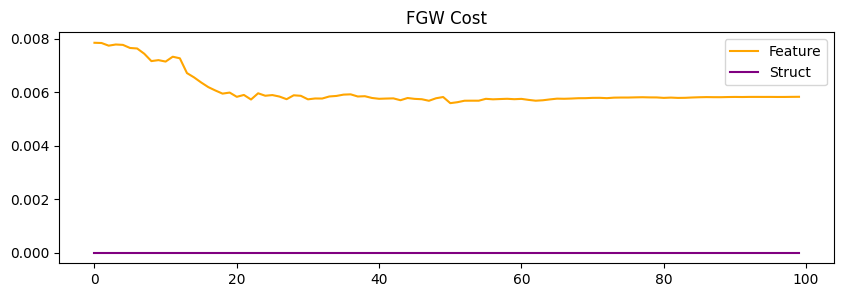

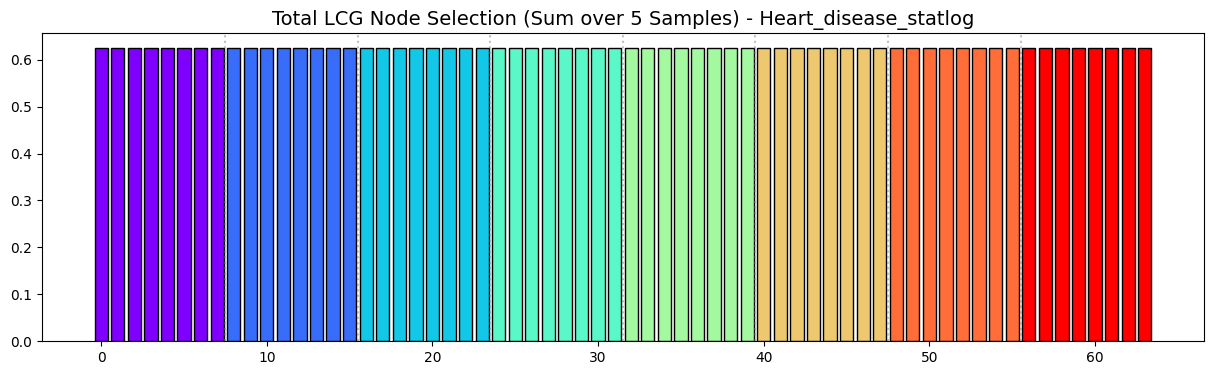

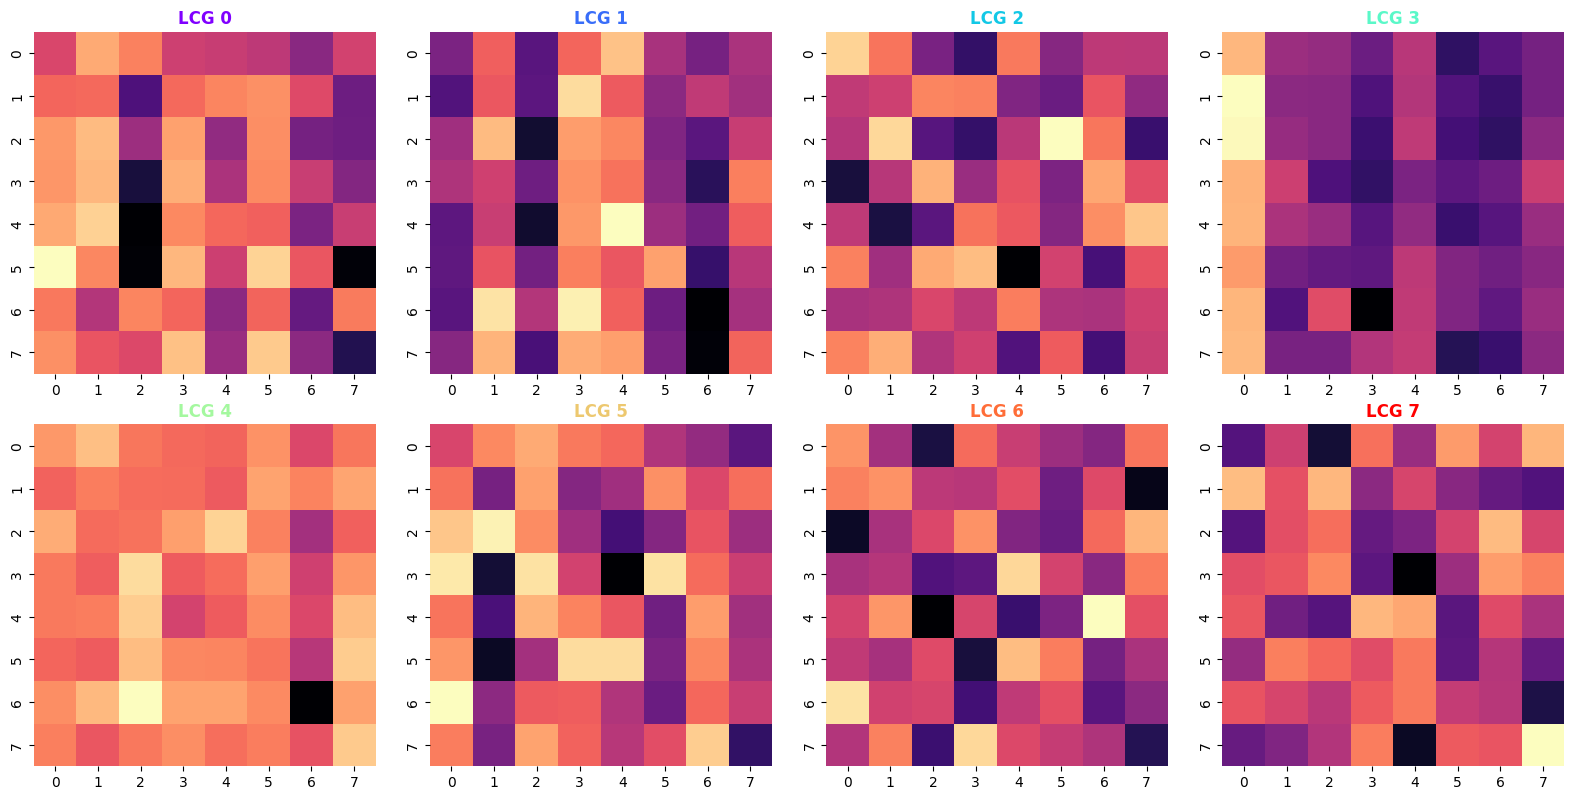

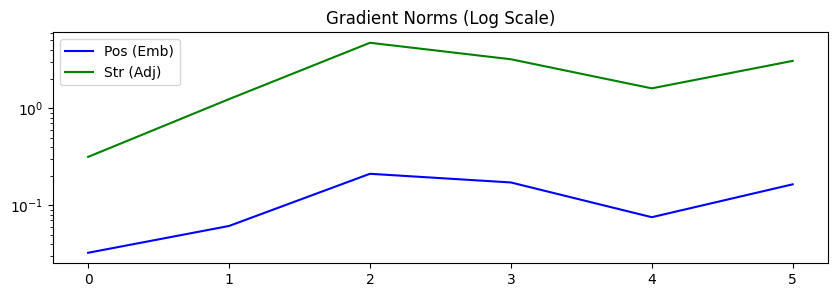

In [5]:
from types import MethodType

# =============================================================================
# 1. Argument & Model Loading
# =============================================================================
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt"

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

print(f">>> Loading Checkpoint from: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# [Config Override]
args.use_lcg = True  # Phase 2 활성화
args.train_epochs = 100
args.source_lr = 0.0001
args.source_data = args.source_data if isinstance(args.source_data, (list, tuple)) else [args.source_data]

fix_seed(args.random_seed)

# 모델 초기화
model = Model(
    args, args.input_dim, args.hidden_dim, args.output_dim, args.dropout_rate, args.llm_model,
    experiment_id="viz_phase2", mode="Full"
).to(device)

sd = ckpt['model_state_dict']
model.load_state_dict(sd, strict=False)
print(">>> Model Loaded (Phase 2).")

# =============================================================================
# 2. [Patch] GraphQuantizer Hook (시각화용)
# =============================================================================
def patched_quantizer_forward(self, source_struct, source_feat, lcg_struct, lcg_feat, batch):
    B, N, D = source_feat.shape 
    M, K, _ = lcg_feat.shape 
    src_feat_exp = source_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
    src_str_exp = source_struct.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
    lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
    lcg_str_exp = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
    
    self.log_step += 1 
    
    dist_commit, plan_commit = self.compute_fgw(src_feat_exp, src_str_exp, lcg_feat_exp, lcg_str_exp)
    d_commit = dist_commit.reshape(B, M)
    pi = torch.softmax(-d_commit / self.soft_tau, dim = 1)

    # Hook
    self.last_pi = pi.detach()
    if plan_commit is not None:
        self.last_plan = plan_commit.detach().reshape(B, M, N, K)

    dist_codebook, _ = self.compute_fgw(src_feat_exp.detach(), src_str_exp.detach(), lcg_feat_exp, lcg_str_exp)
    d_codebook = dist_codebook.reshape(B, M)
    pi_detached = pi.detach() 
    loss_codebook = (pi_detached * d_codebook).sum(dim=1).mean() 
    loss_commitment = (pi_detached * d_commit).sum(dim=1).mean() 
    
    e_beta = getattr(self, 'entropy_beta', 0.0)
    entropy = -(pi * torch.log(pi + 1e-9)).sum(dim=1).mean()
    vq_loss = loss_codebook + self.vq_beta * loss_commitment - e_beta * entropy
    return lcg_feat, lcg_struct, pi, vq_loss

# 속성 추가 및 메서드 바인딩
if not hasattr(model.graph_quantizer, 'last_pi'): model.graph_quantizer.last_pi = None
if not hasattr(model.graph_quantizer, 'last_plan'): model.graph_quantizer.last_plan = None
model.graph_quantizer.forward = MethodType(patched_quantizer_forward, model.graph_quantizer)
print(">>> [Patch] GraphQuantizer hooked.")

# =============================================================================
# 3. Data & Optimizer Setup
# =============================================================================
sources = args.source_data
trains, vals, tests = [], [], []
print(f">>> Loading Sources: {sources}")

for name in sources:
    # [Safe Loading] Dict/Tuple 리턴 타입 모두 처리
    res = prepare_embedding_dataloaders(args, name)
    if isinstance(res, dict): tr, va, te = res['loaders']
    else: tr, va, te, nc = res
    trains.append(tr); vals.append(va); tests.append(te)

tr_step = make_step(trains, mode='random', seed=args.random_seed)
val_steps = [MultiSourceStepLoader([vals[i]], mode='round', seed=args.random_seed, src_idx=i) for i in range(len(vals))]

base_params = [p for n, p in model.named_parameters() if "latent_graph" not in n and "gnn_experts" not in n and p.requires_grad]
lcg_params = [p for n, p in model.named_parameters() if ("latent_graph" in n or "gnn_experts" in n) and p.requires_grad]

optimizer = optim.Adam([{'params': base_params, 'lr': args.source_lr * 0.1}, {'params': lcg_params, 'lr': args.source_lr * 0.2}], weight_decay=1e-5)
scheduler = make_warmup_cosine_epochs(optimizer, args.train_epochs, warmup_epochs=max(1, int(0.1*args.train_epochs)), min_lr_mult=0.01)

is_bin = (args.output_dim == 1) or (args.num_classes == 2)
criterion = nn.BCEWithLogitsLoss() if is_bin else nn.CrossEntropyLoss()

# =============================================================================
# 4. Training Loop
# =============================================================================
collector = VizCollector(args, sources, tr_step.loaders, device, save_interval=20)
print(f"\n>>> Start Joint Training (Phase 2) for {args.train_epochs} Epochs...")

for epoch in range(args.train_epochs):
    # Safe Train
    train_loss = binary_train(model, tr_step, criterion, optimizer, device) if is_bin else multi_train(model, tr_step, criterion, optimizer, device)
    if scheduler: scheduler.step()
    if hasattr(model, 'current_epoch'): model.current_epoch = epoch + 1

    # Eval
    l_aucs, g_aucs, l_loss_sum, g_loss_sum = [], [], 0.0, 0.0
    for vl in val_steps:
        res_g, res_l = binary_evaluate(model, vl, criterion, device) if is_bin else multi_evaluate(model, vl, criterion, device)
        l_loss_sum += res_l[0]; g_loss_sum += res_g[0]
        if is_bin:
            l_aucs.append(roc_auc_score(res_l[1], res_l[2]))
            g_aucs.append(roc_auc_score(res_g[1], res_g[2]))
        else:
            lb = label_binarize(res_l[1], classes=range(res_l[2].shape[1]))
            l_aucs.append(roc_auc_score(lb, res_l[2], multi_class='ovr', average='macro'))
            g_aucs.append(roc_auc_score(lb, res_g[2], multi_class='ovr', average='macro'))

    fgw_val = getattr(model, 'fgw_loss', torch.tensor(0.0)).item()
    collector.step(
        epoch, model,
        losses={'local': l_loss_sum/len(val_steps), 'global': g_loss_sum/len(val_steps)},
        aucs={'local_mean': np.mean(l_aucs), 'global_mean': np.mean(g_aucs), 'local_per_src': l_aucs, 'global_per_src': g_aucs},
        costs={'feat': fgw_val, 'struct': 0.0}
    )
    
    if (epoch + 1) % 10 == 0:
        print(f"[Ep {epoch+1:03d}] Loss(L/G): {l_loss_sum/len(val_steps):.4f}/{g_loss_sum/len(val_steps):.4f} | AUC(L/G): {np.mean(l_aucs):.4f}/{np.mean(g_aucs):.4f} | FGW: {fgw_val:.4f}")

print("\n>>> Training Finished. Plotting...")
plot_training_results(collector.history, n_graphs=args.n_graphs, n_nodes=args.n_nodes)